In [20]:
import numpy as np 
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import json
import os
import pandas as pd
from pathlib import Path
import pickle
import histlite as hl
import sys
sys.path.append(os.path.abspath("../../../"))
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
import kingmaker_fork.likelihood_analysis.analysis_helpers.fitting_plots as fplt
from kingmaker_fork.likelihood_analysis.analysis_helpers.get_bin_egdes import get_bin_info
from kingmaker_fork.likelihood_analysis.utils.trial_runner_config_loading import restore_king_trial_runner
import csky as cy
from kingmaker_fork.likelihood_analysis.utils.parallel_king_trials import get_many_fits_from_trials


from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Load Rayleigh Benchmark runs

In [21]:
rayleigh_benchmark_path = Path('/data/user/fkrafft/csky_gfu_tests/rayleigh_benchmark_gamma_2.5')

In [22]:
rayleigh_data = {}
for file in rayleigh_benchmark_path.glob("rayleigh_sens_*.json"):
    with open(file) as f:
        sens_data = json.load(f)

    # extract sin(dec) from filename
    # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
    name = file.stem

    sindec_str = name.split("sindec_")[1].split("_N_")[0]
    sin_dec = float(sindec_str)

    # store inside your existing data object
    rayleigh_data[sin_dec] = sens_data    

## Load King runs

In [23]:
run_folder = Path('/data/user/fkrafft/king_llh_binning_run')

In [24]:
king_data = {}
for run in [p for p in run_folder.iterdir() if p.is_dir()]:
    input_dir = Path(run)
    king_data[run.name] = {}
    for file in input_dir.glob("TEST_king_sens_*.json"):

        with open(file) as f:
            sens_data = json.load(f)

        # extract sin(dec) from filename
        # e.g. TEST_king_sens_sindec_0.2_N_1000_min_count_300_angErr12.json
        name = file.stem

        sindec_str = name.split("sindec_")[1].split("_N_")[0]
        sin_dec = float(sindec_str)

        # store inside your existing data object
        king_data[run.name][sin_dec] = sens_data 
    #if no files: remove   
    if king_data[run.name] == {}:
        king_data.pop(run.name)

In [25]:
len(list(king_data.keys()))

112

In [26]:
region_ratios = {key: [] for key in list(rayleigh_data.keys())}

In [27]:
def get_binning_from_path(folder_path):
    path = Path(folder_path)
    pkl_file =list( path.glob("king_trial_runner_config*.pkl"))[0]
    with open(pkl_file, "rb") as f:
        cfg = pickle.load(f)

    return cfg["parametrization_bins"]


## Plot sensitivities

In [32]:

def plot_flux(folder_name, show_title = True):
        
    sin_decs = sorted(list(king_data[folder_name].keys()))
    y = []
    yerr = []
    rayleigh_y = []
    rayleigh_yerr = []
    filtered_sin_decs = []
    

    for k in sin_decs:
        king_d = king_data[folder_name][k]
        rayleigh_d = rayleigh_data[k]

        flux = king_d["flux"]
        flux_err = king_d["flux_err"]

        # skip invalid King points
        try:
            flux = float(king_d["flux"])
            flux_err = float(king_d["flux_err"])
        except (TypeError, ValueError):
            continue

        if not (np.isfinite(flux) and np.isfinite(flux_err)):
            continue

        y.append(flux)
        yerr.append(flux_err)

        rayleigh_y.append(rayleigh_d["flux"])
        rayleigh_yerr.append(rayleigh_d["flux_err"])
        
        region_ratios[k].append(flux/rayleigh_d['flux'])
        # keep x in sync with the filtered arrays
        filtered_sin_decs.append(k)
    x = np.asarray(filtered_sin_decs)
    y = np.asarray(y)
    yerr = np.asarray(yerr)

    rayleigh_y = np.asarray(rayleigh_y)
    rayleigh_yerr = np.asarray(rayleigh_yerr)

    # total score metric
    llh_score = np.mean(y / rayleigh_y)


    ratio = y / rayleigh_y

    ratio_err = ratio * np.sqrt(
        (yerr / y)**2 +
        (rayleigh_yerr / rayleigh_y)**2
    )
    # --- plotting ---
    fig, (ax, ax_diff) = plt.subplots(
        2,
        1,
        figsize=(10, 6),
        sharex=True,
        gridspec_kw={"height_ratios": [3, 1], "hspace": 0.05},
    )
    if show_title:
        ax.set_title(folder_name + r", $\overline{r}_s =$" + str(llh_score.round(4)))

    # top panel
    ax.set_yscale("log")

    ax.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        ls="dotted",
        marker="",
        capsize=3,
        zorder=3,
        label=r"King",
    )

    ax.errorbar(
        x,
        rayleigh_y,
        yerr=rayleigh_yerr,
        ls="dotted",
        marker="",
        capsize=3,
        zorder=3,
        label=r"Rayleigh",
    )

    ax.legend()
    ax.set_xlim(-0.85, 0.85)
    ax.set_ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
    ax.grid(which="both", zorder=1)

    # bottom panel
    ax_diff.axhline(1, color="black", lw=1, ls="--")
    ax_diff.axvspan(-0.17, -0.03, color="grey", alpha=0.2, zorder=2)

    ax_diff.errorbar(
        x,
        ratio,
        yerr=ratio_err,
        ls="dotted",
        capsize=3,
        zorder=3,
        color="black",
    )

    ax_diff.set_xlabel(r"$\sin{(\mathrm{dec})}$")
    ax_diff.set_ylabel(r"$\Phi_{\rm King}/\Phi_{\rm Rayleigh}$")
    ax_diff.legend()
    ax_diff.grid(which="both", zorder=1)
    plt.show()
    return llh_score

/tmp/ipykernel_3928879/40256637.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_diff.legend()


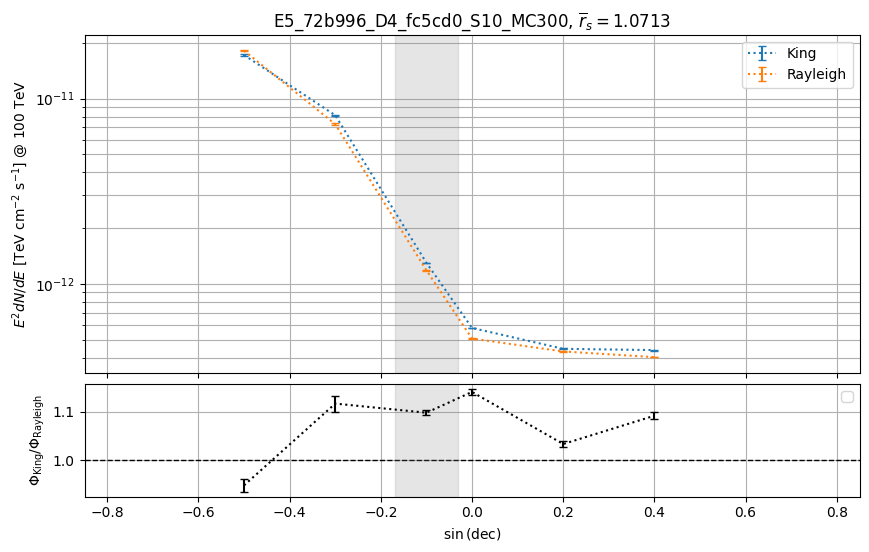

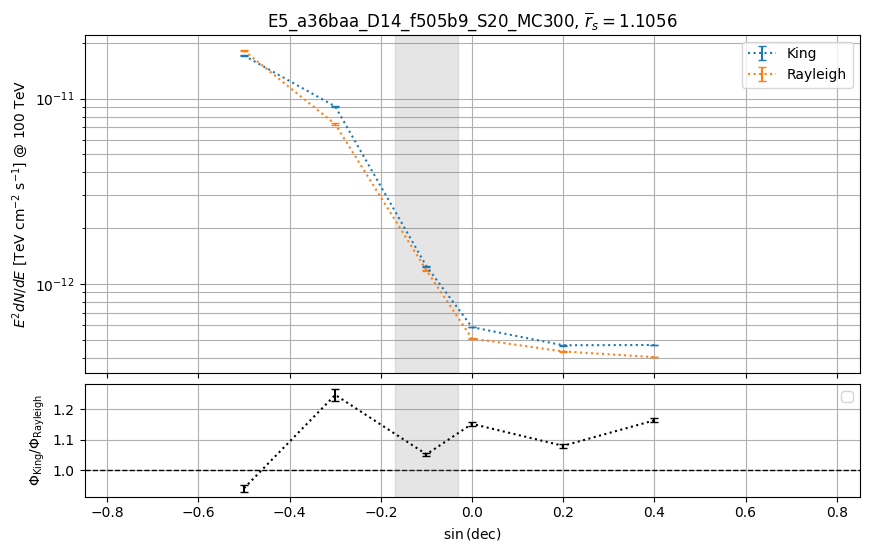

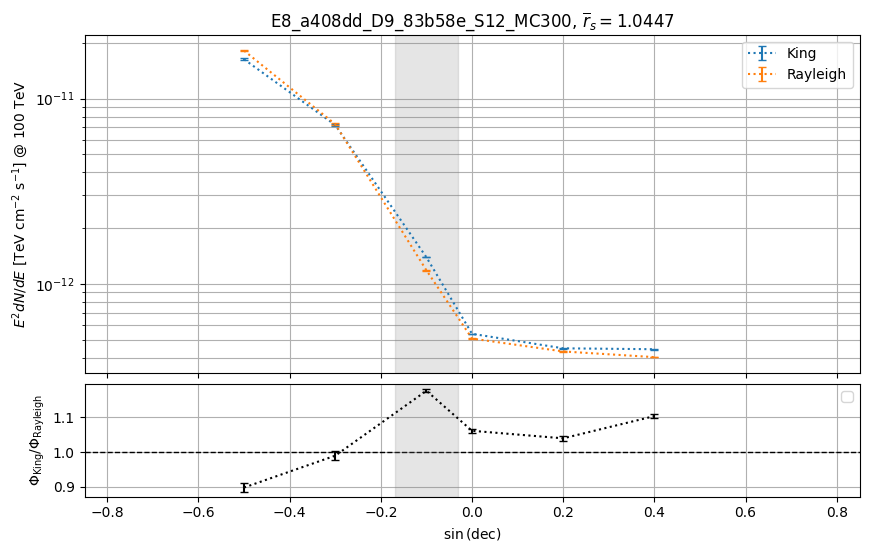

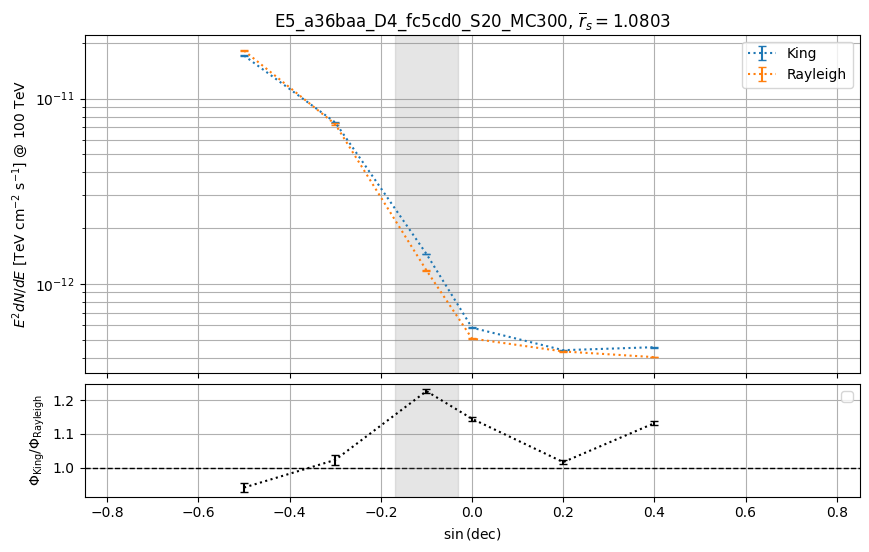

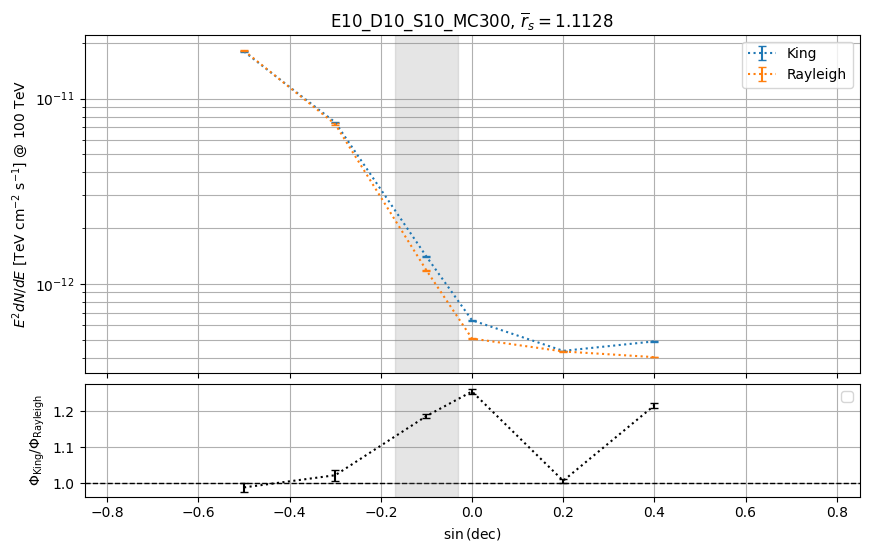

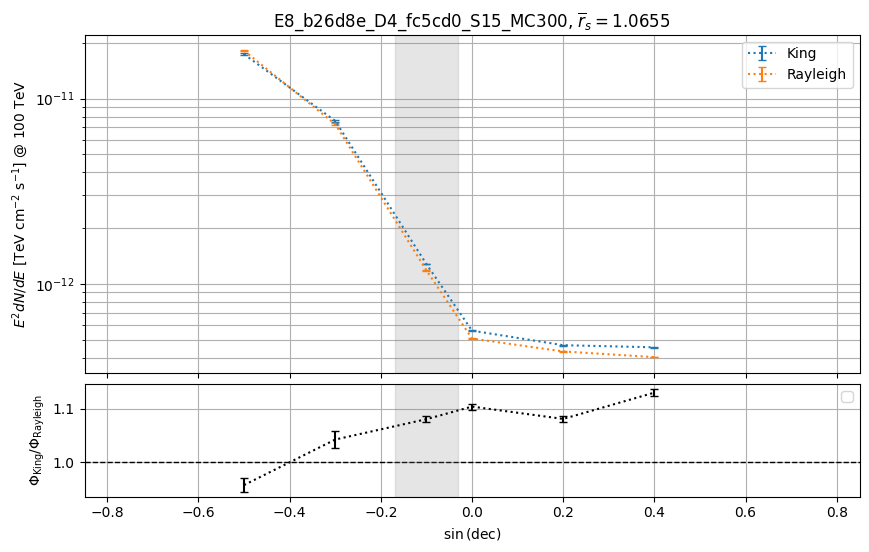

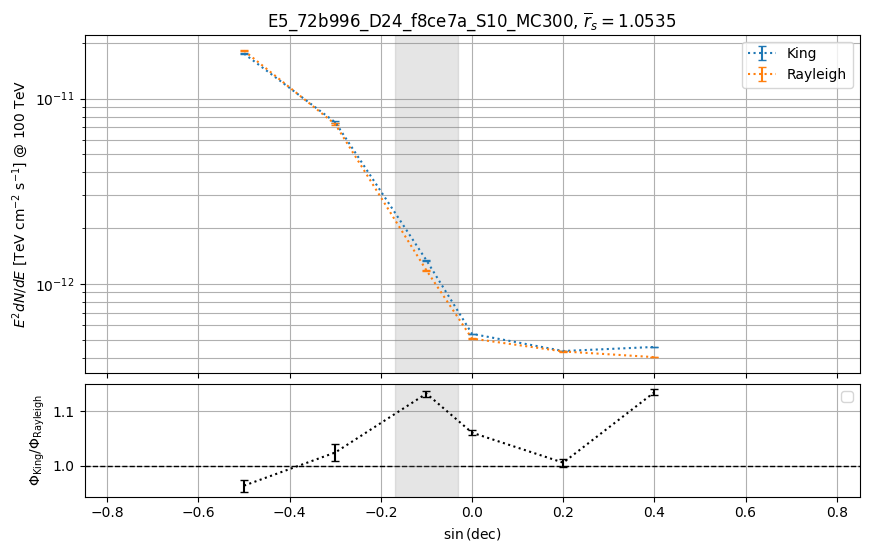

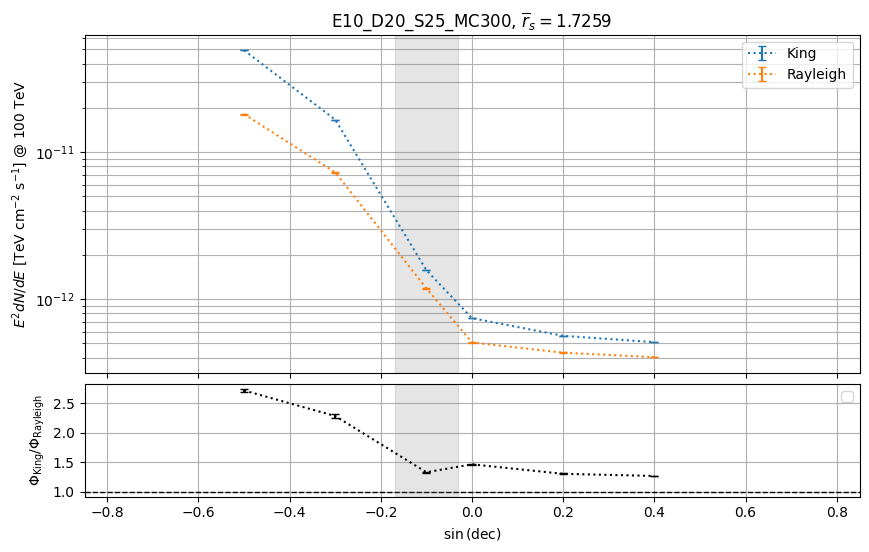

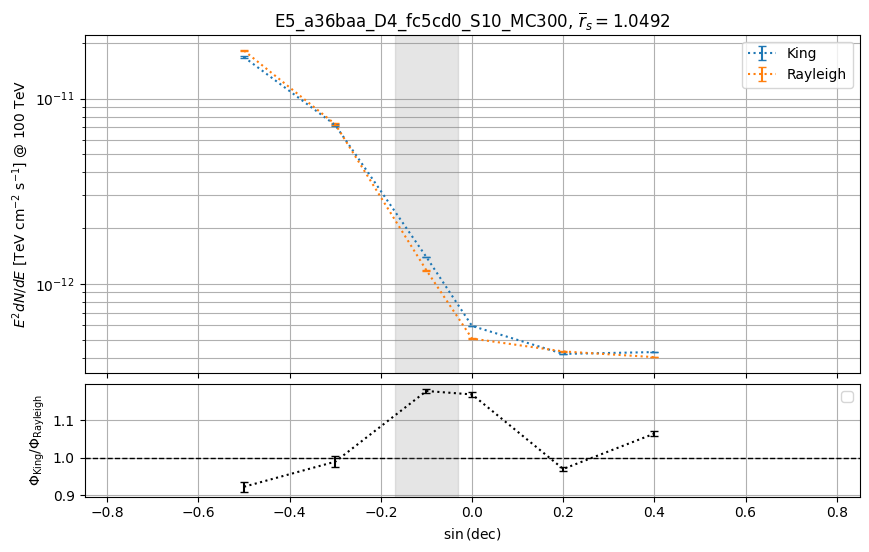

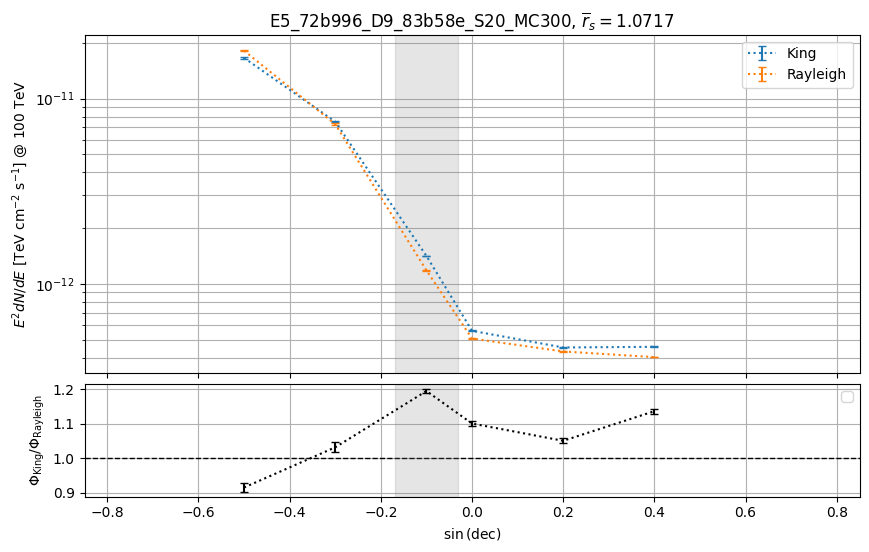

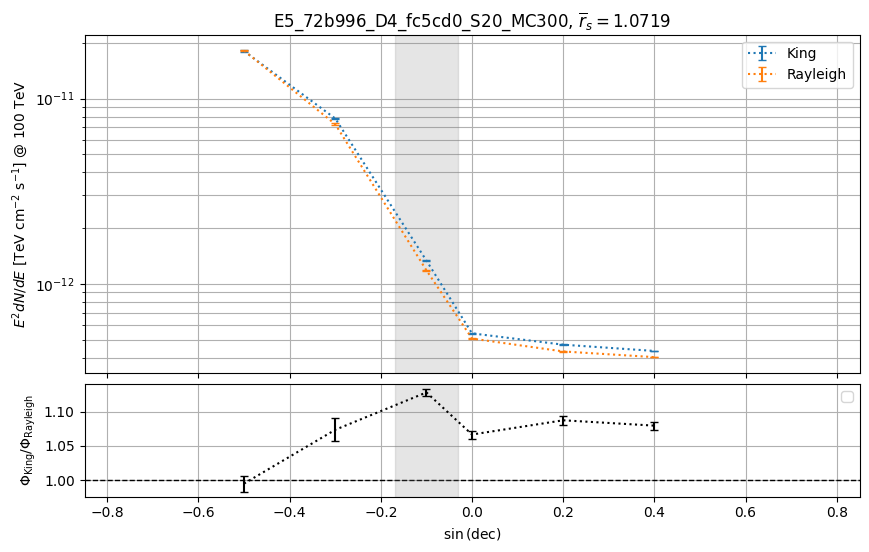

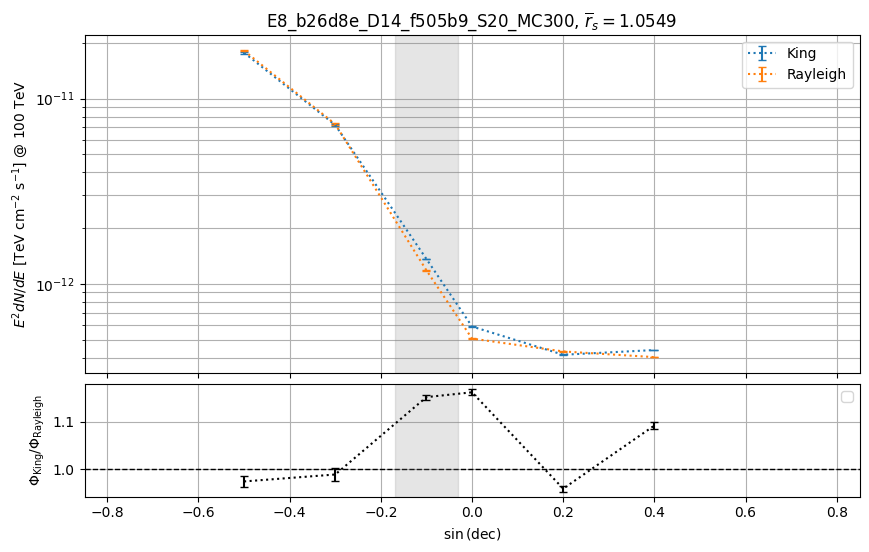

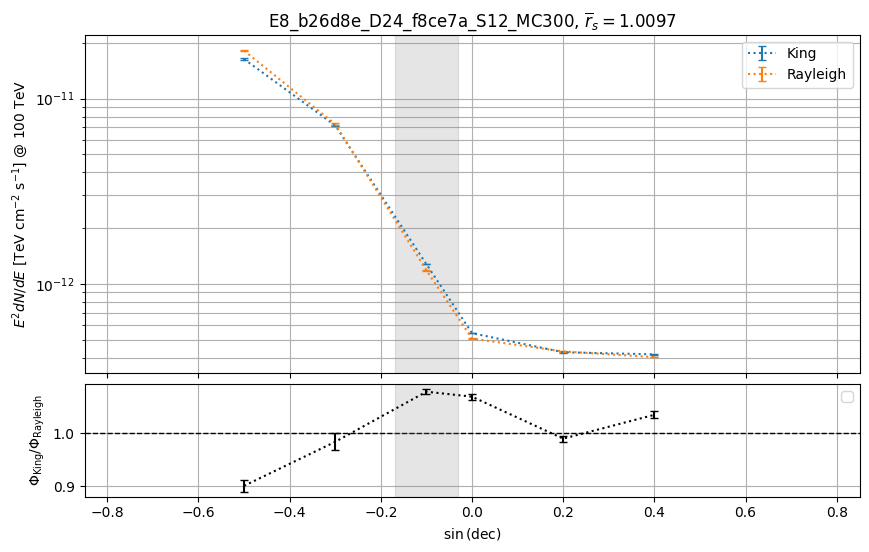

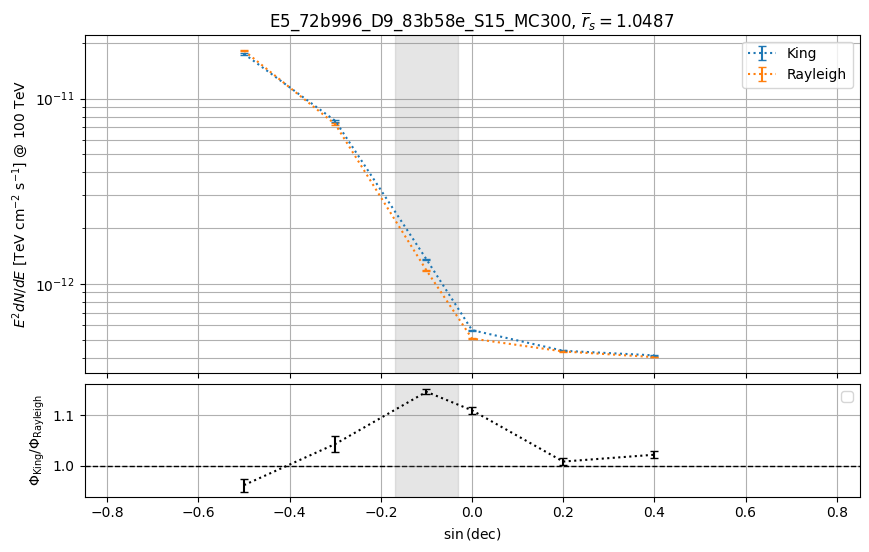

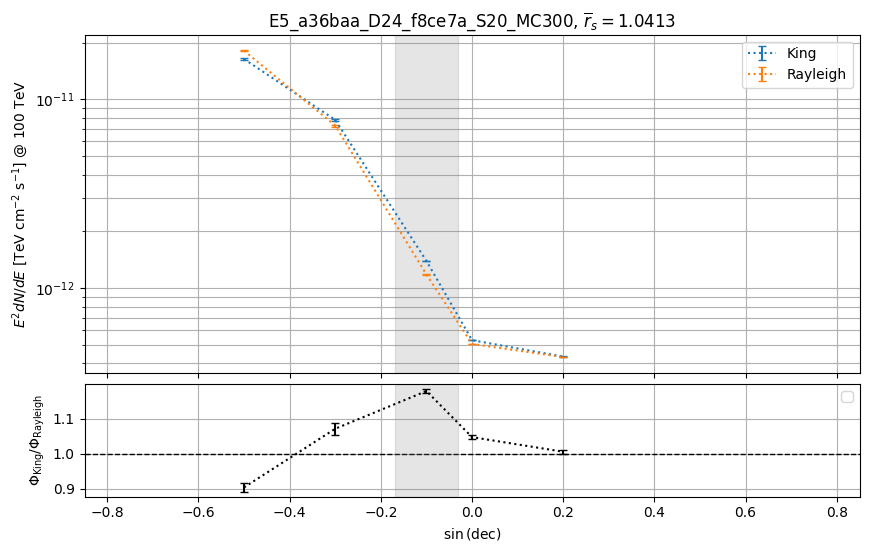

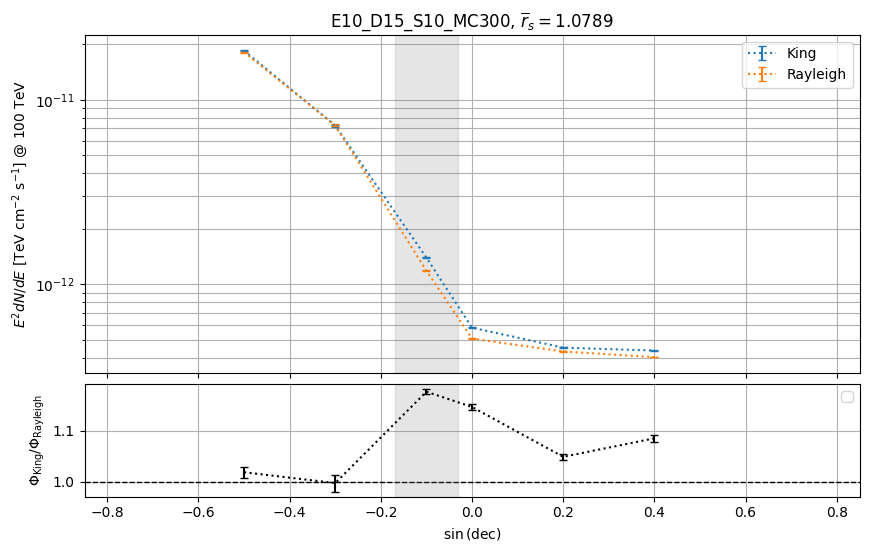

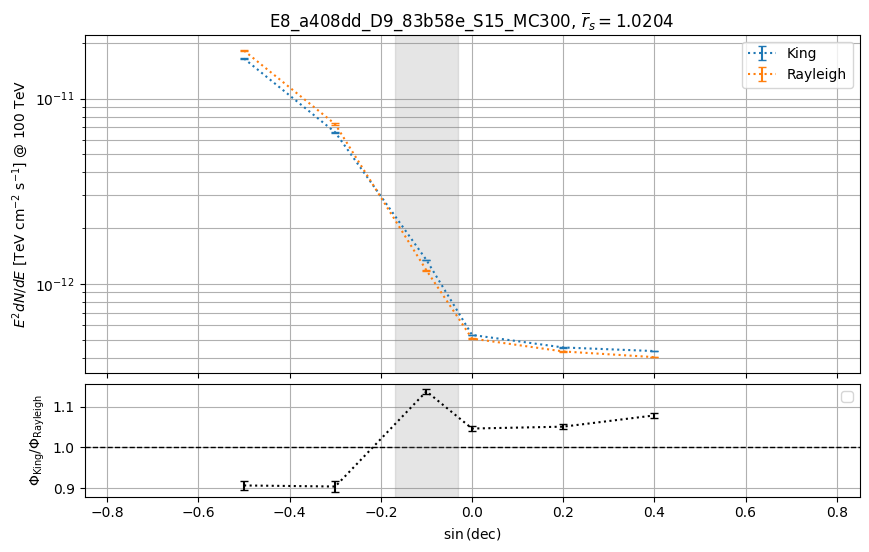

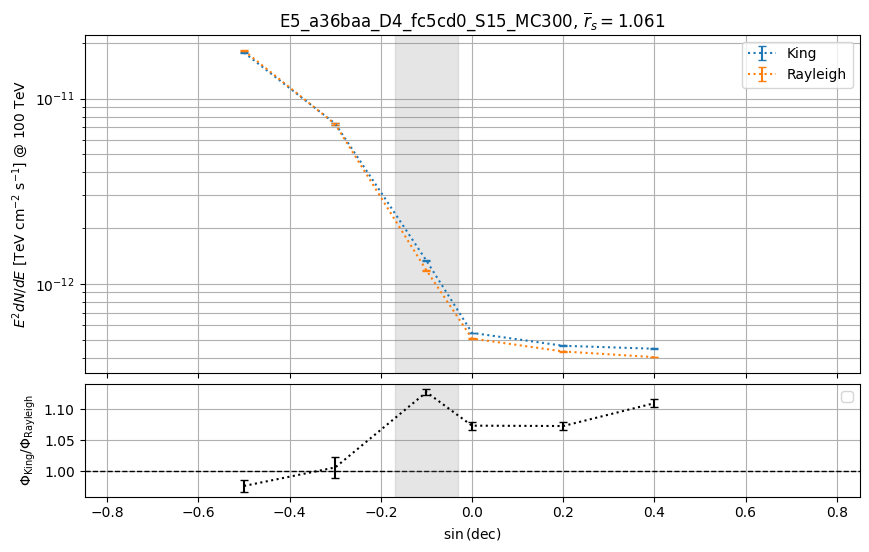

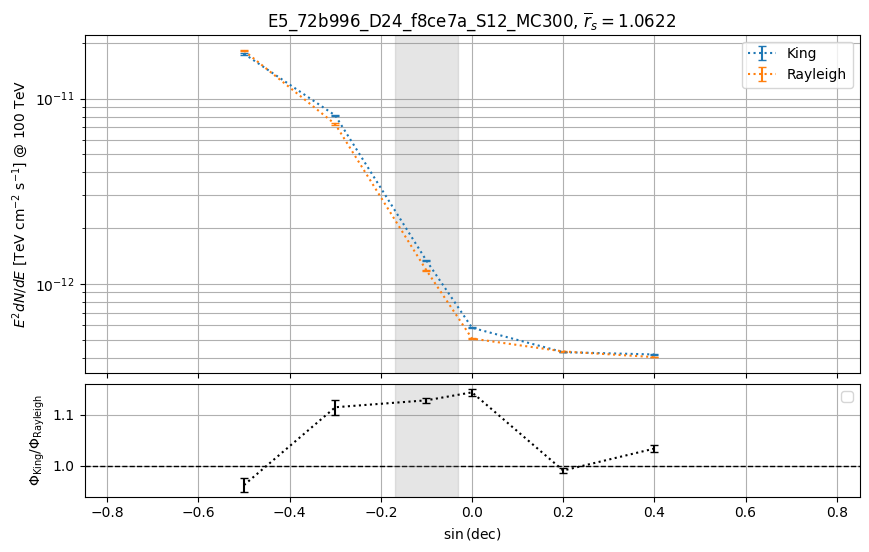

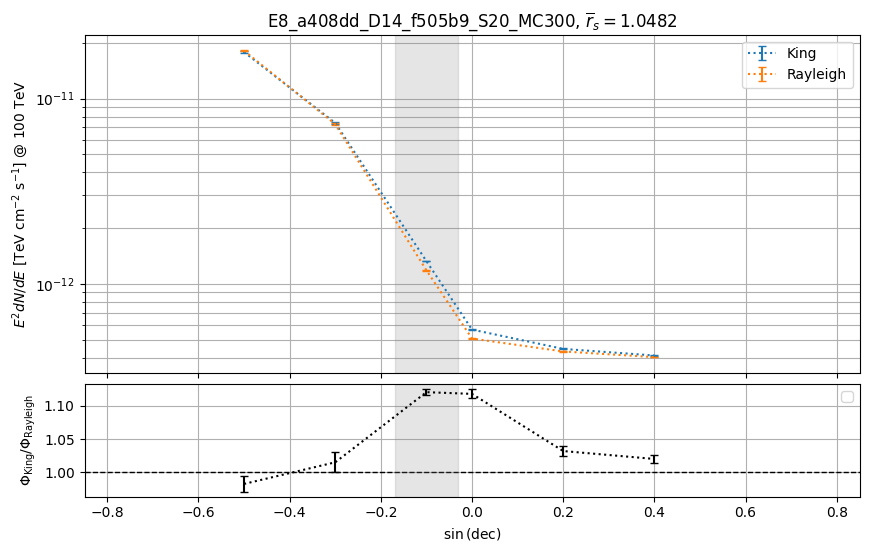

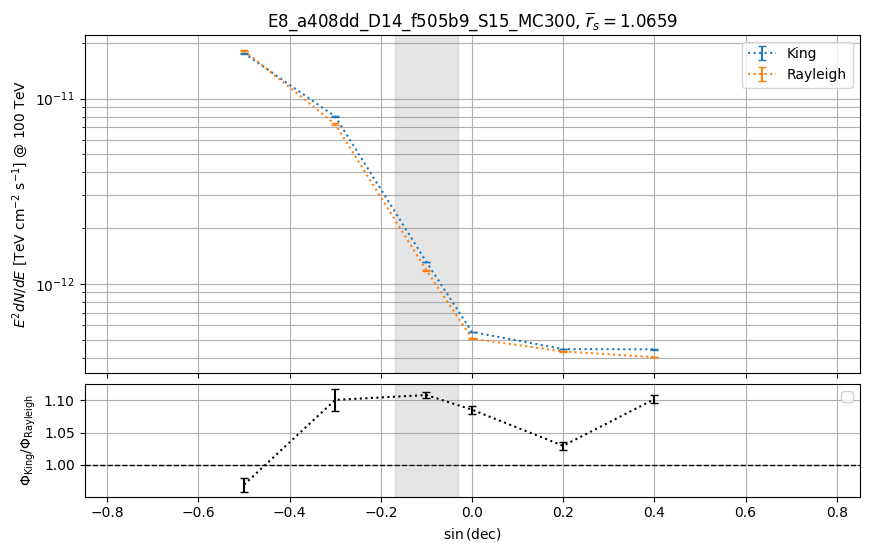

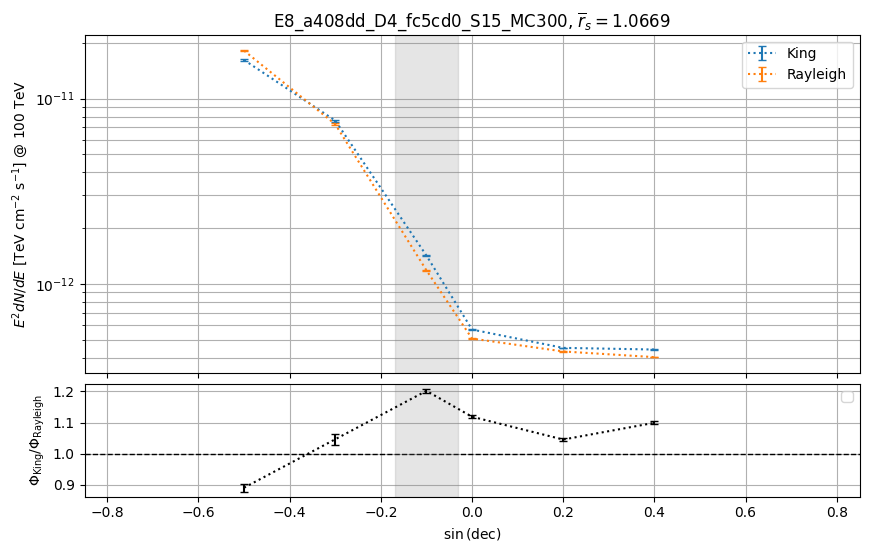

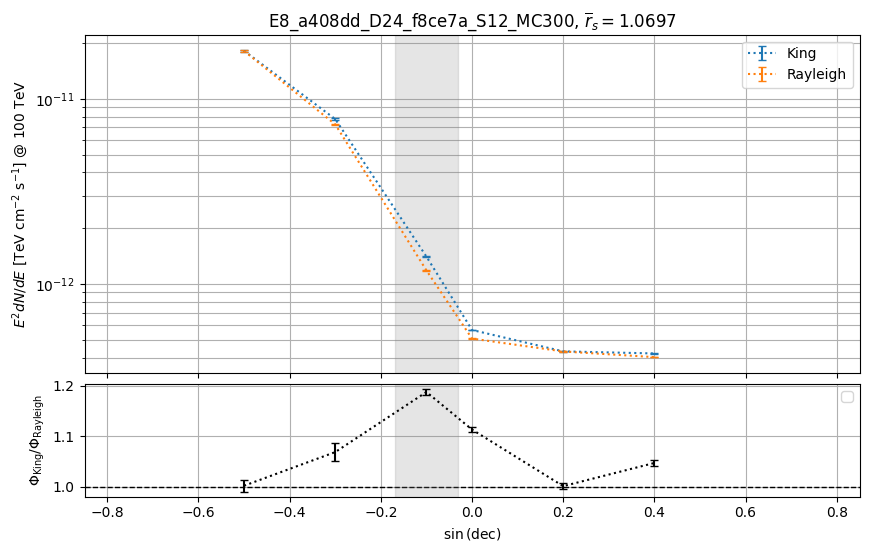

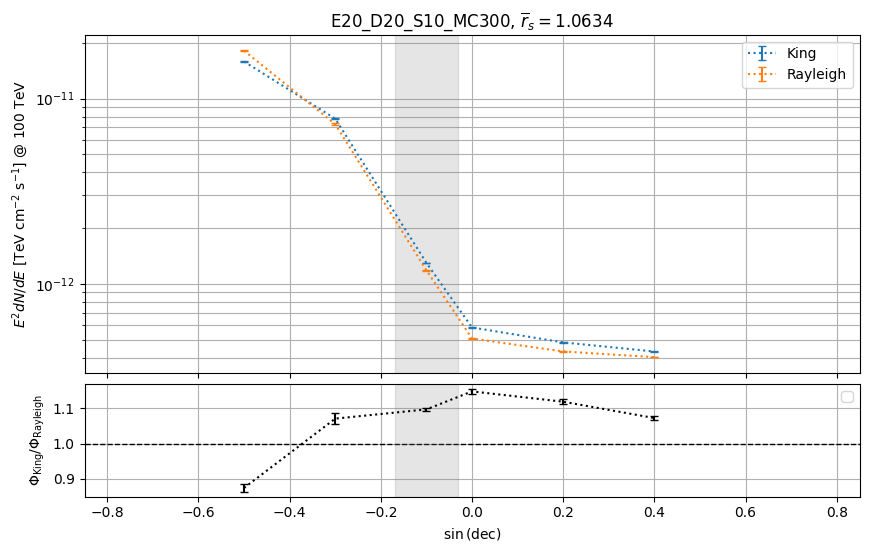

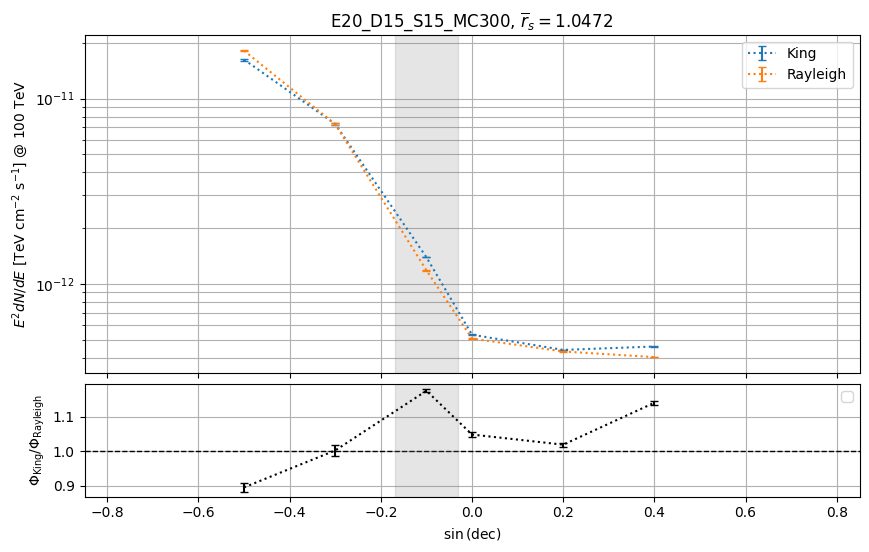

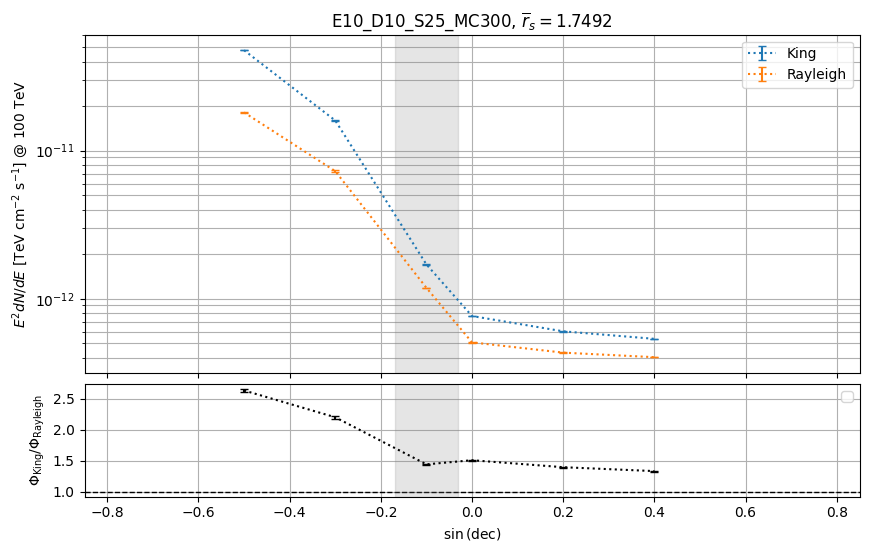

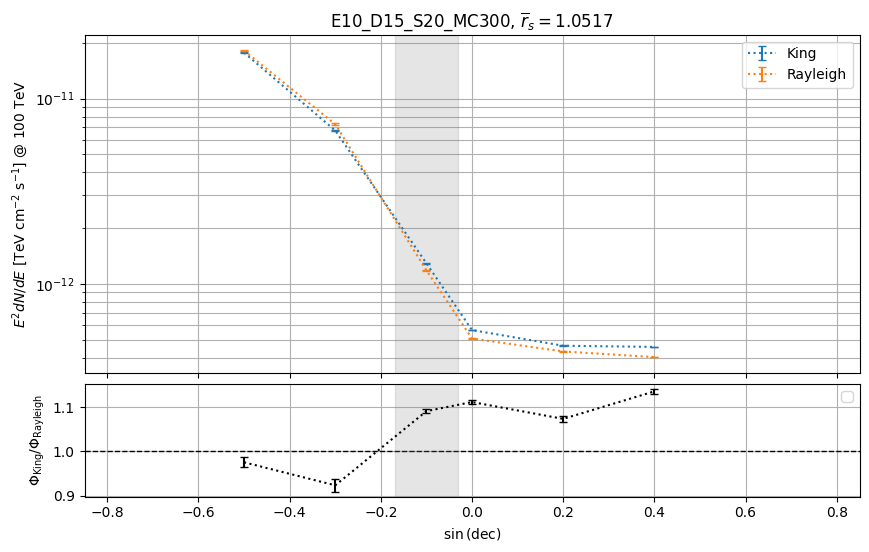

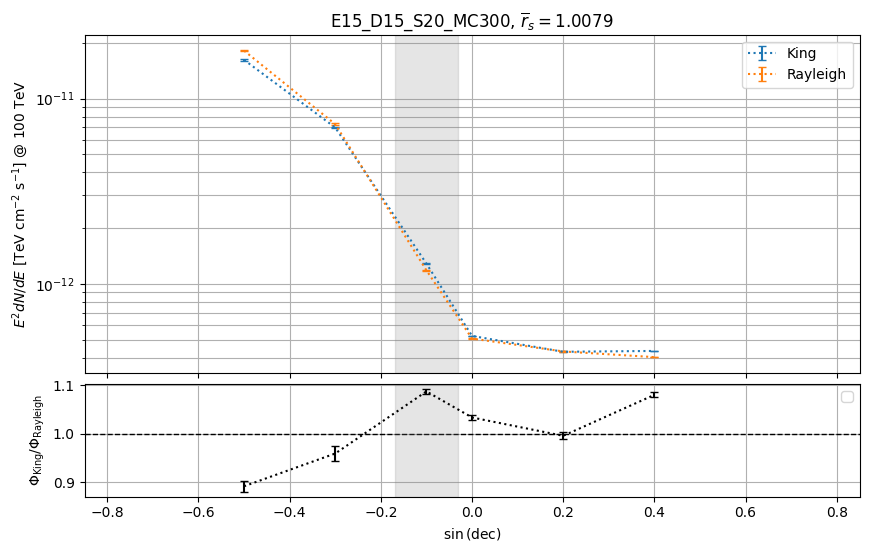

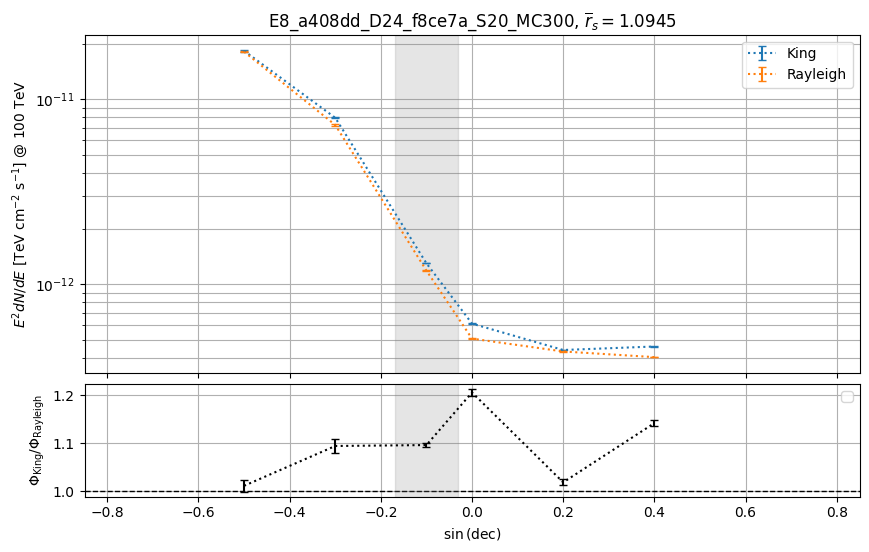

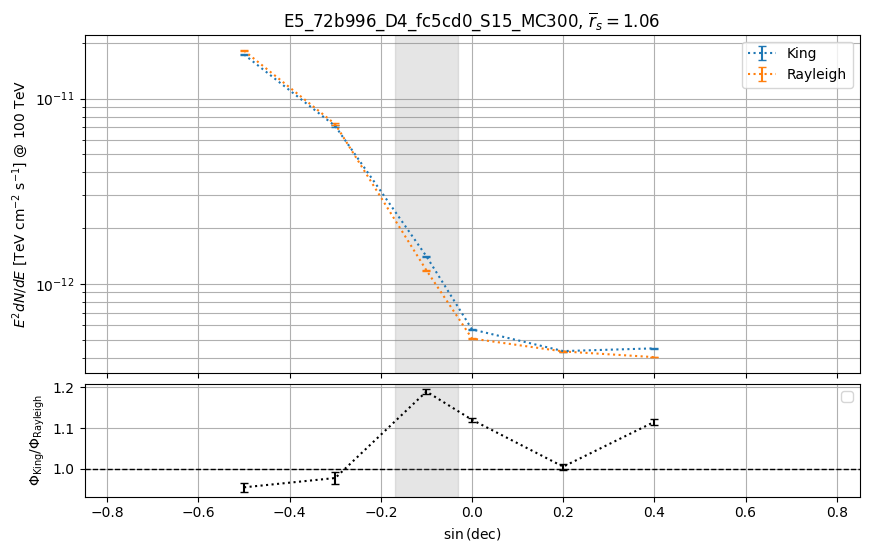

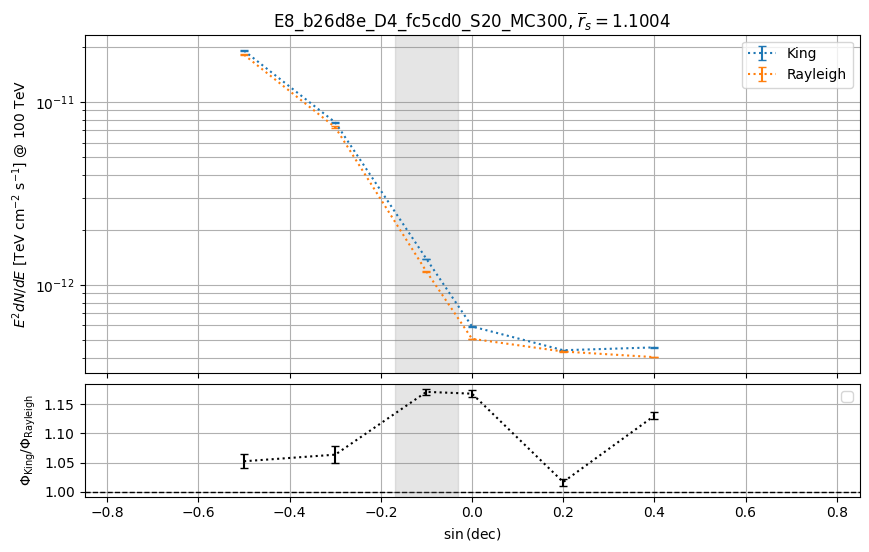

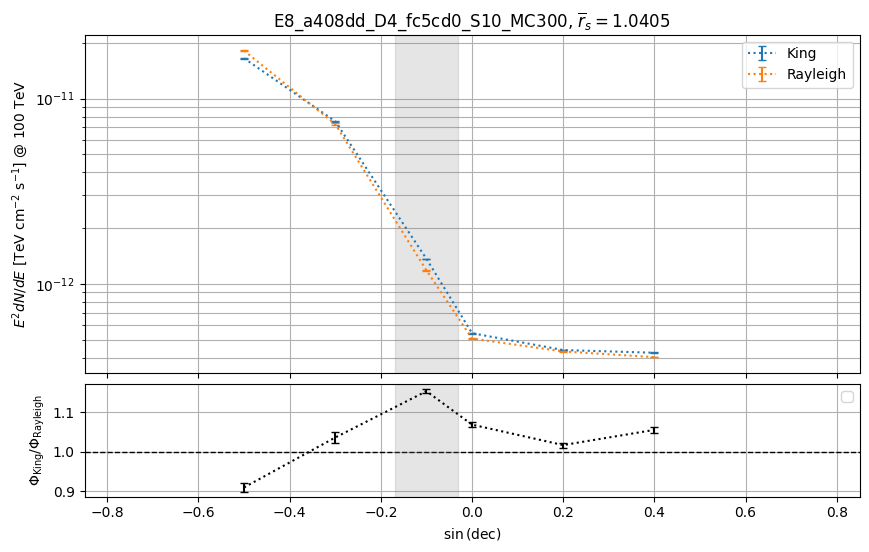

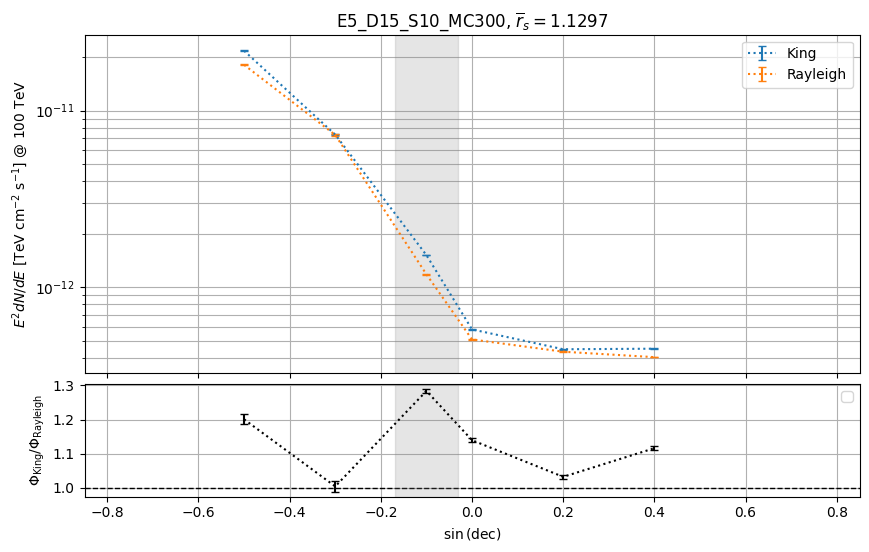

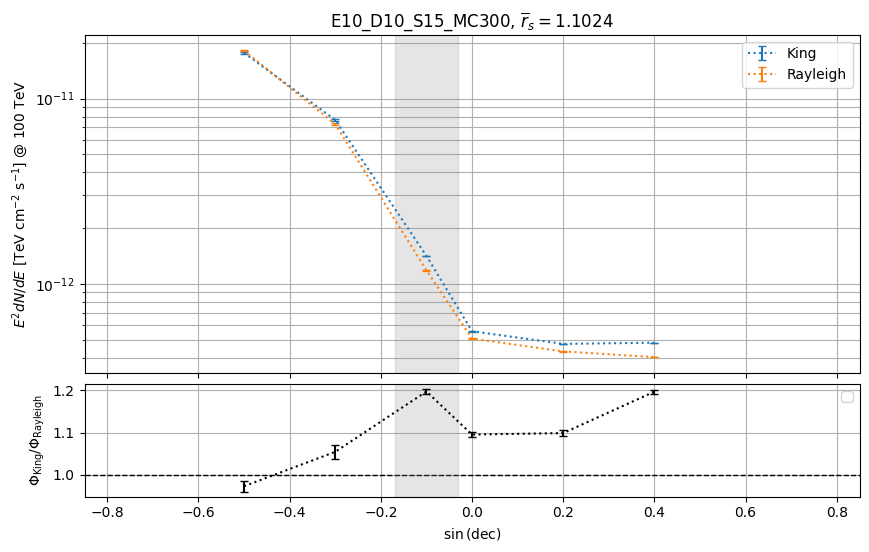

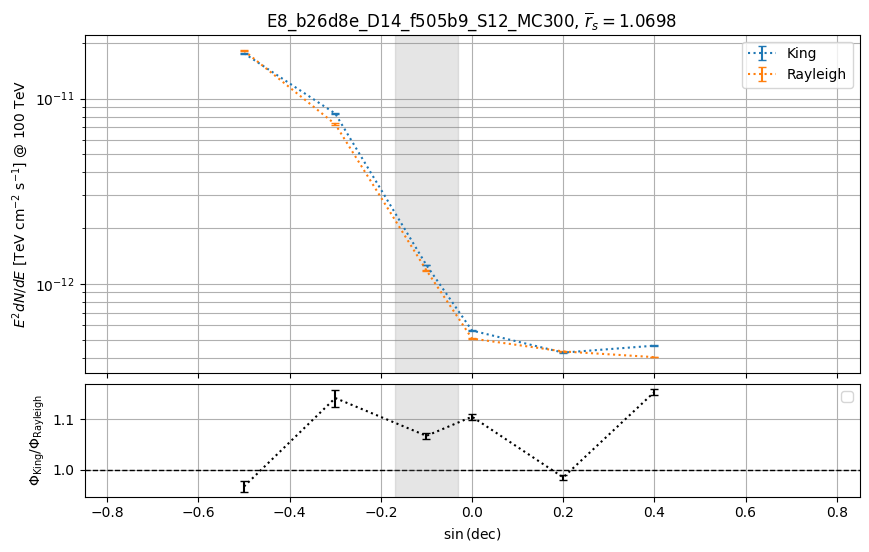

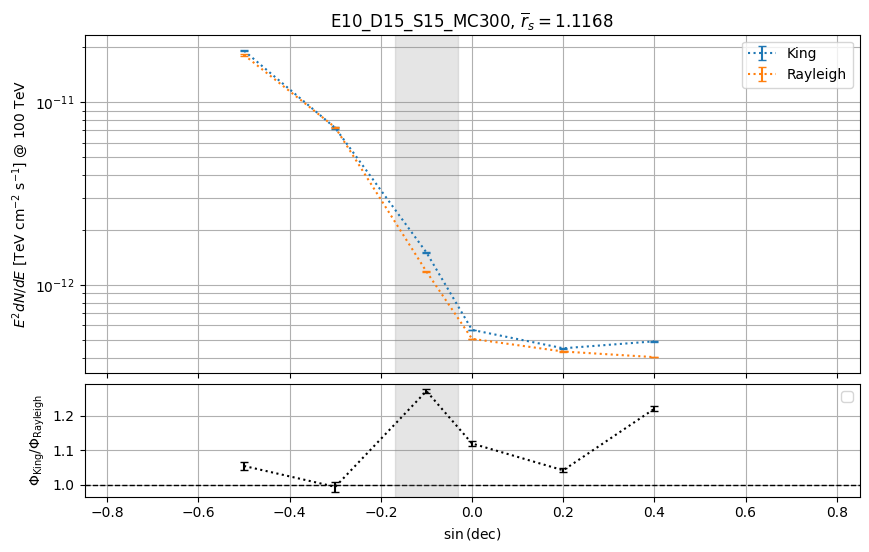

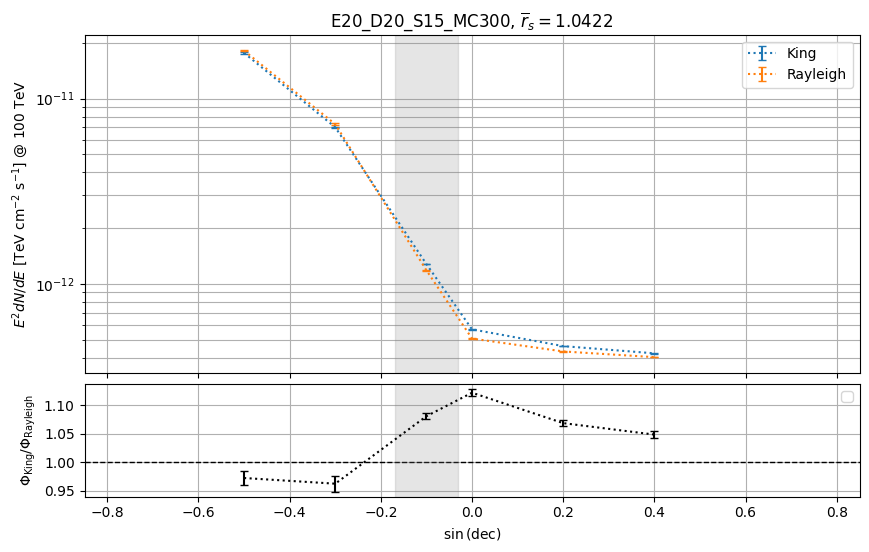

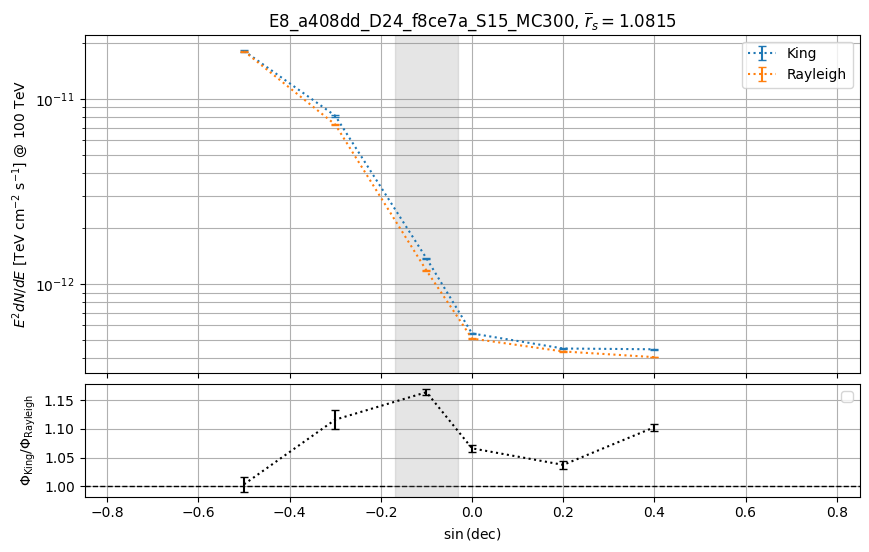

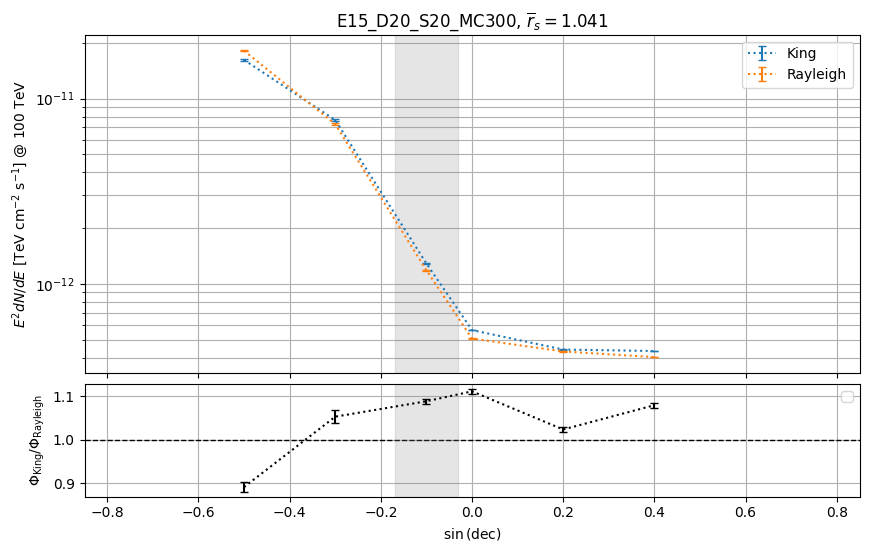

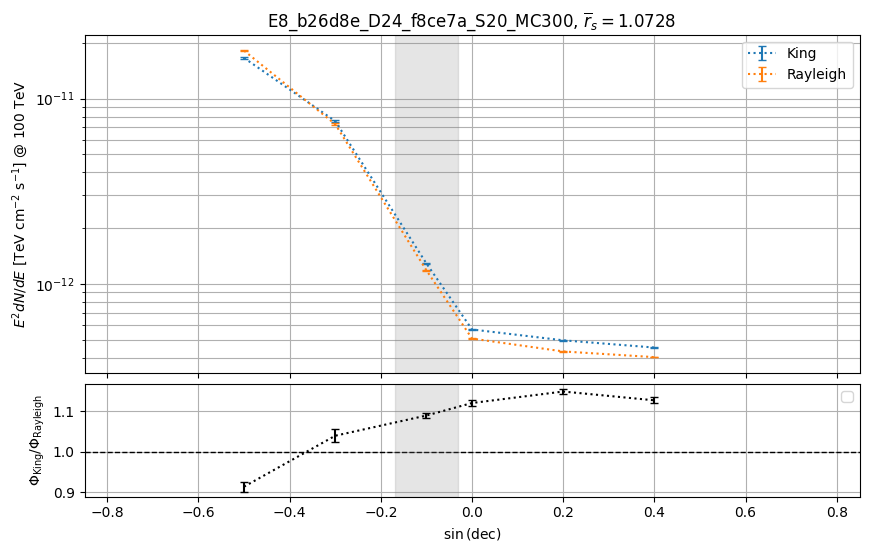

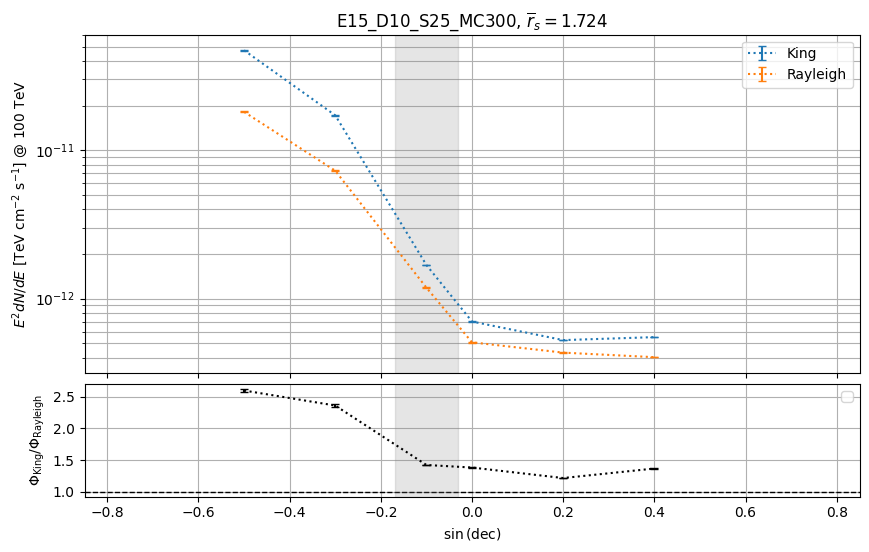

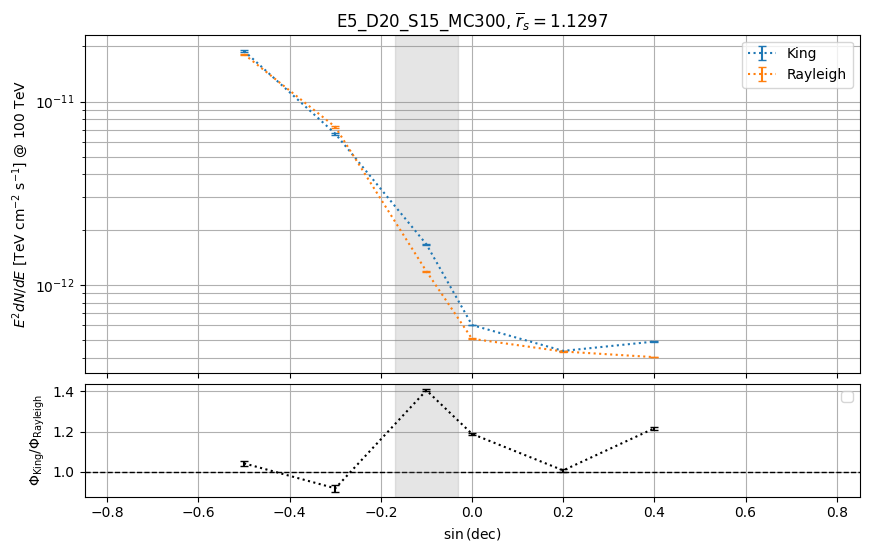

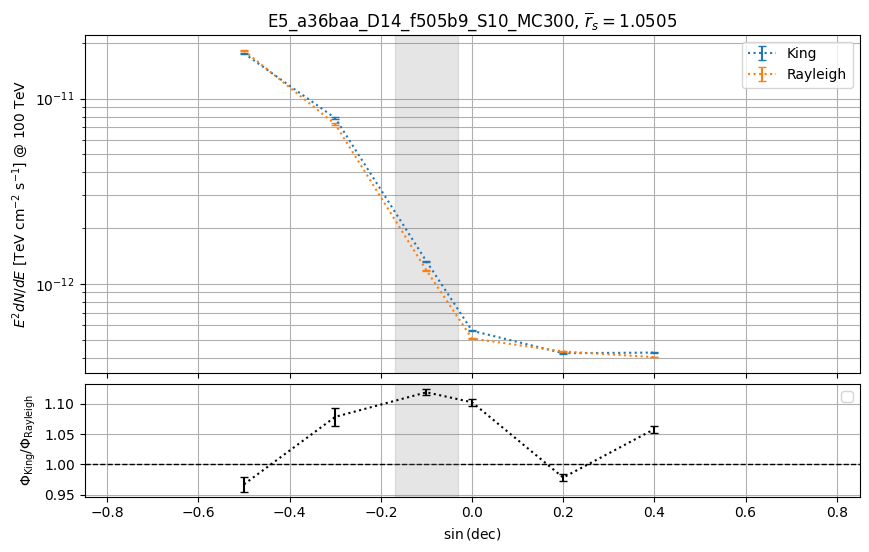

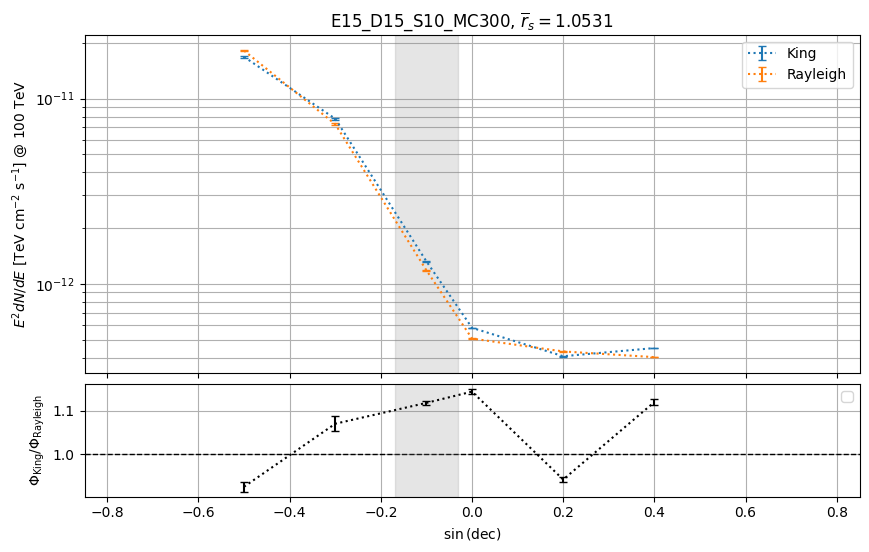

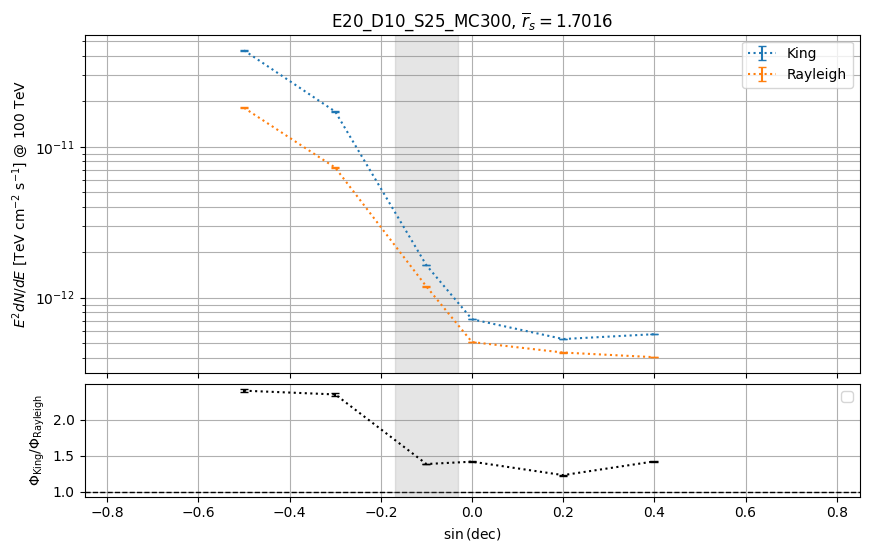

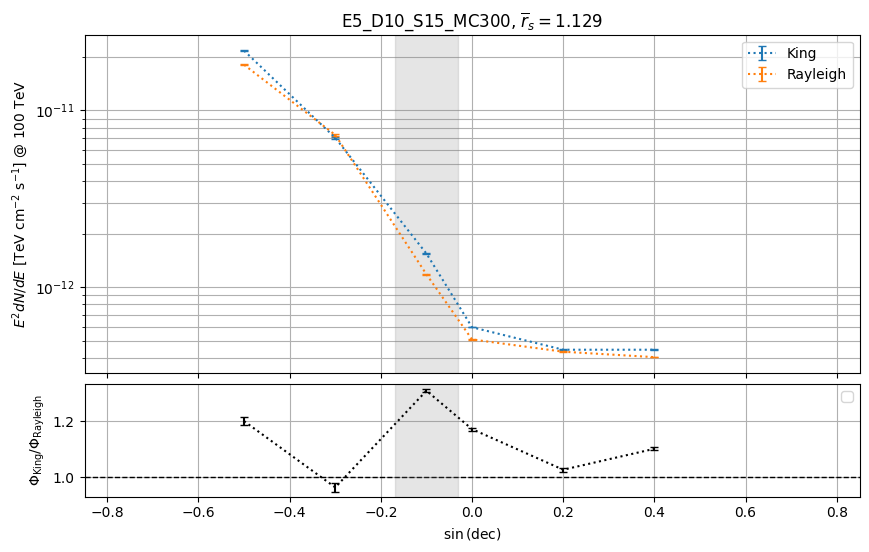

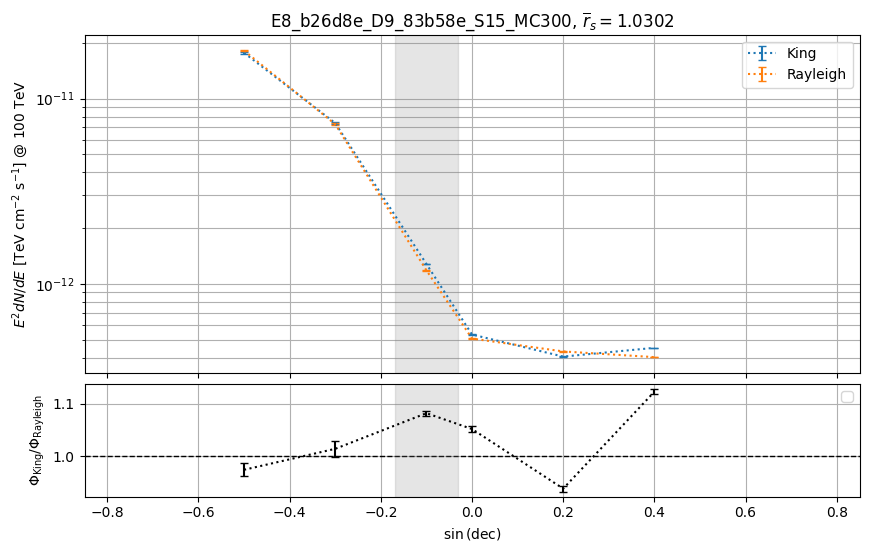

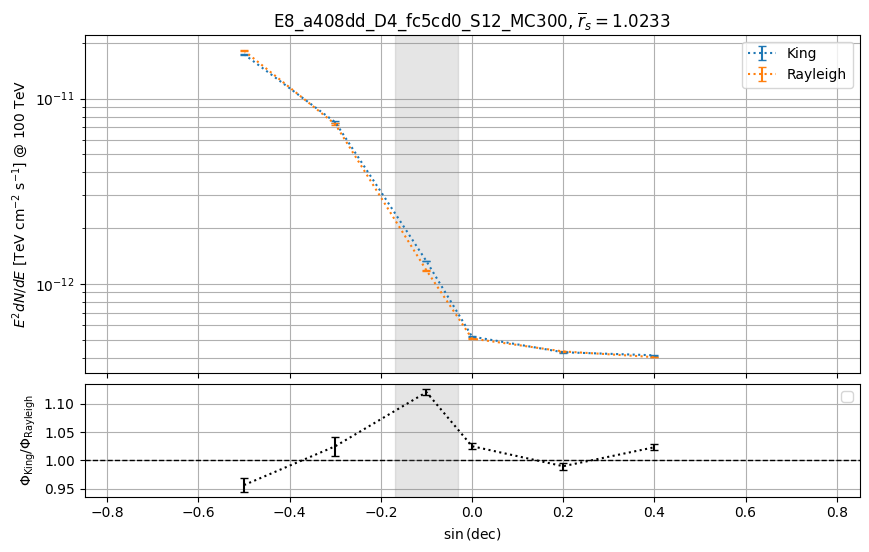

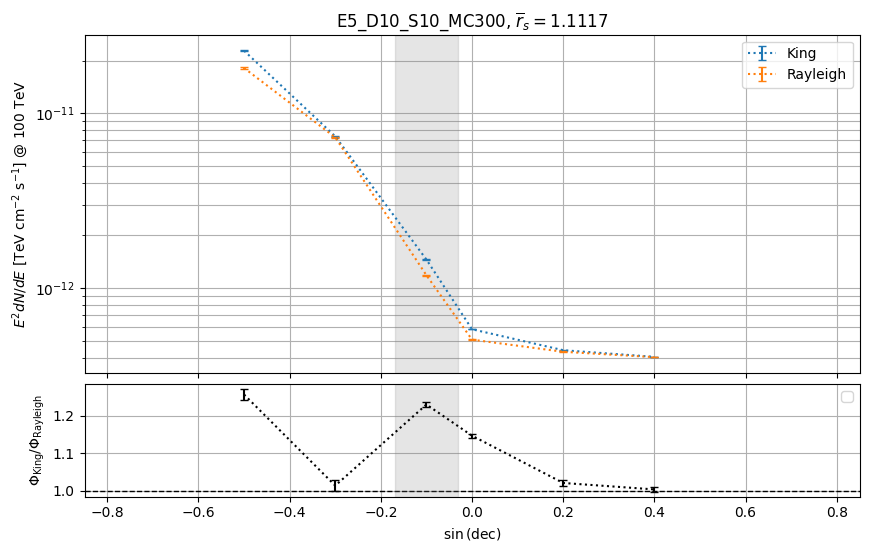

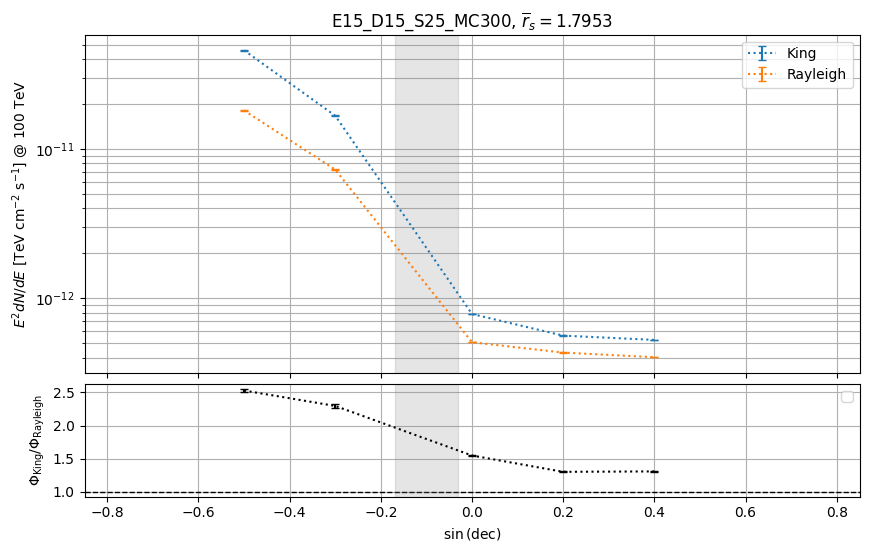

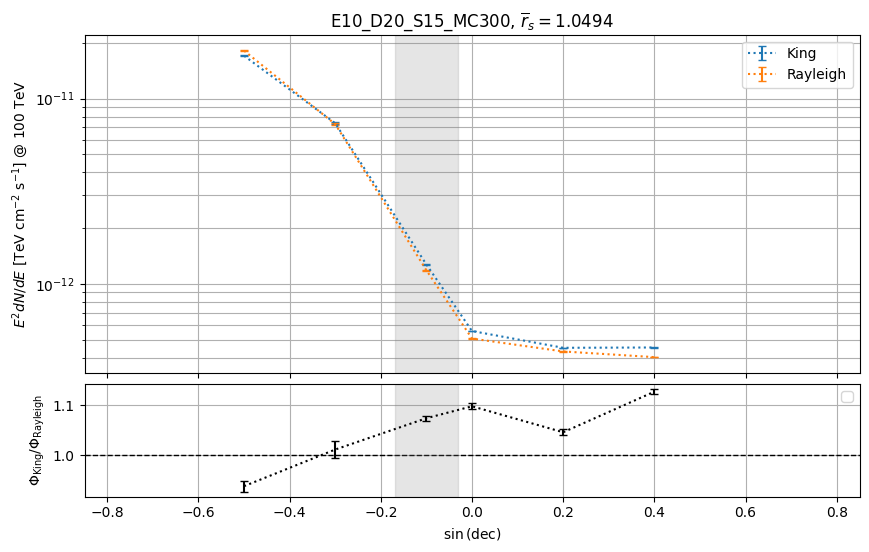

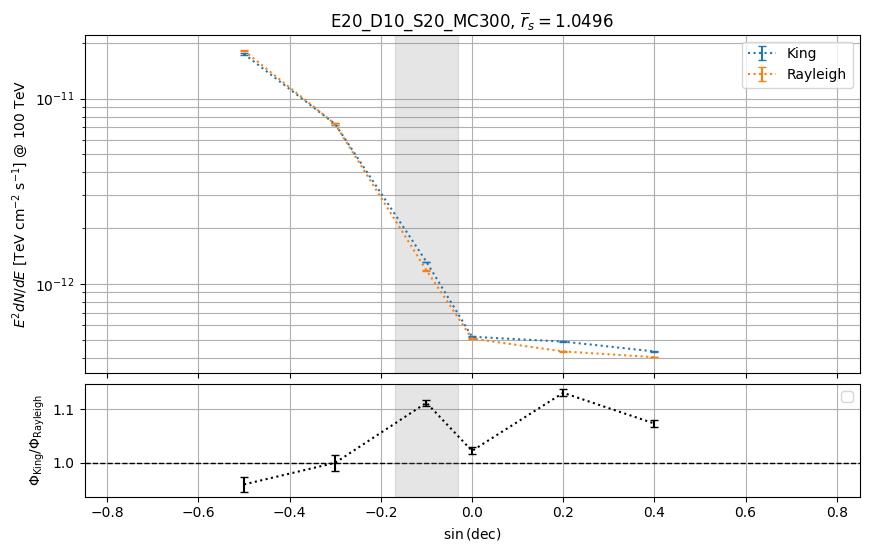

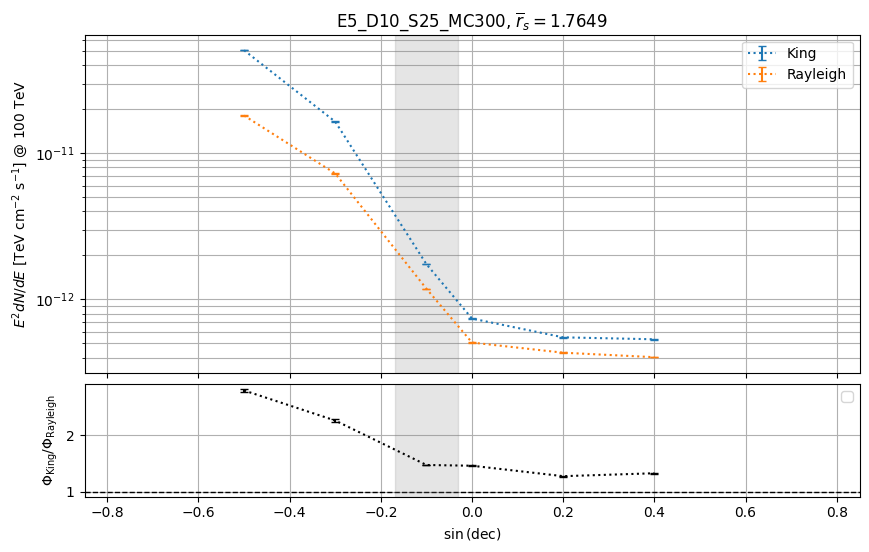

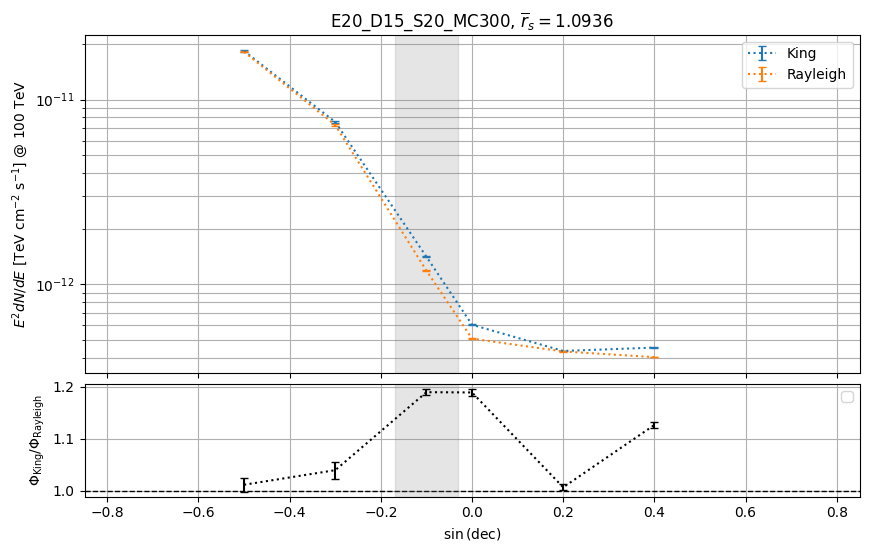

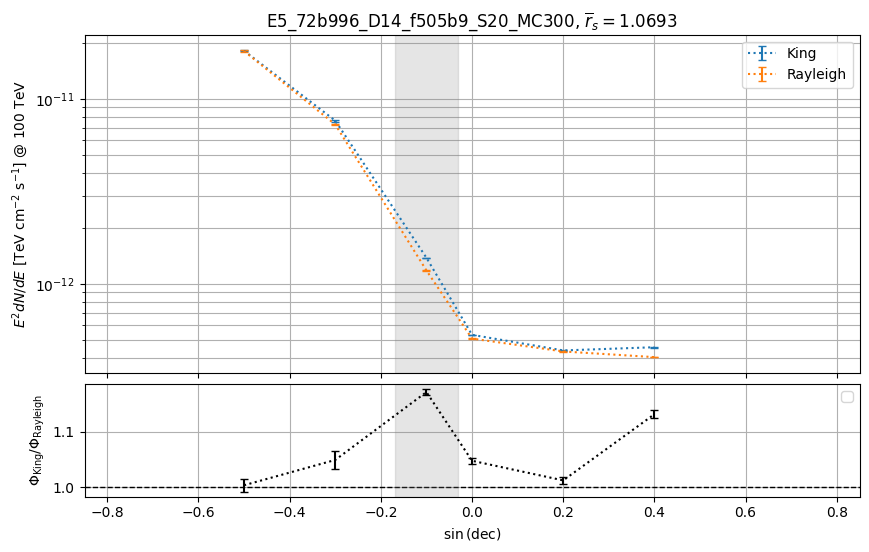

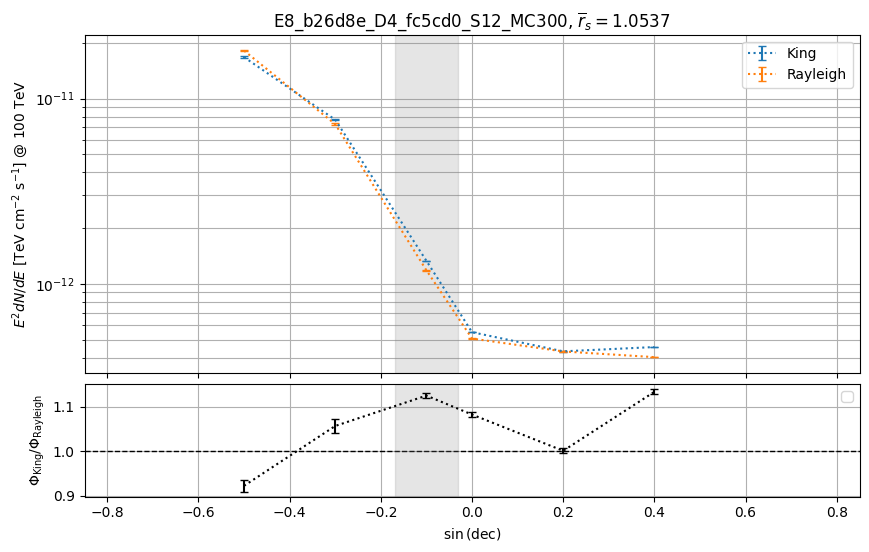

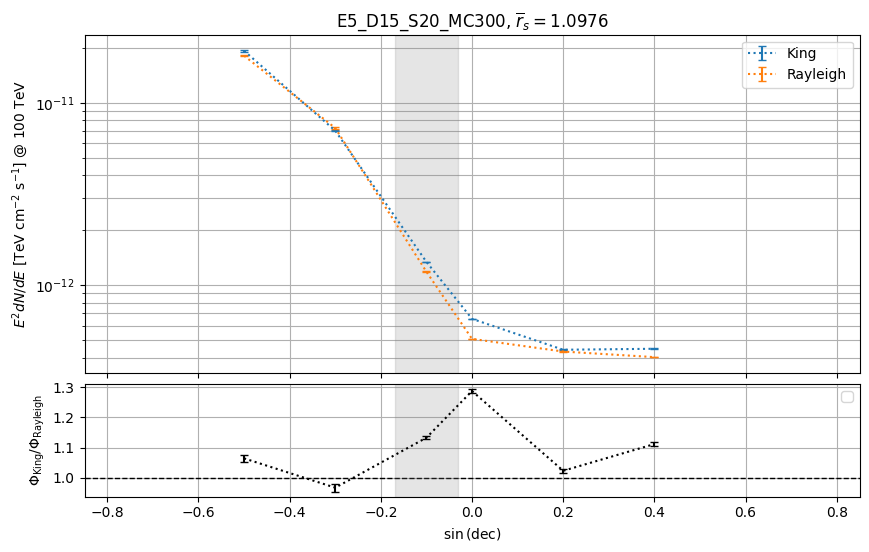

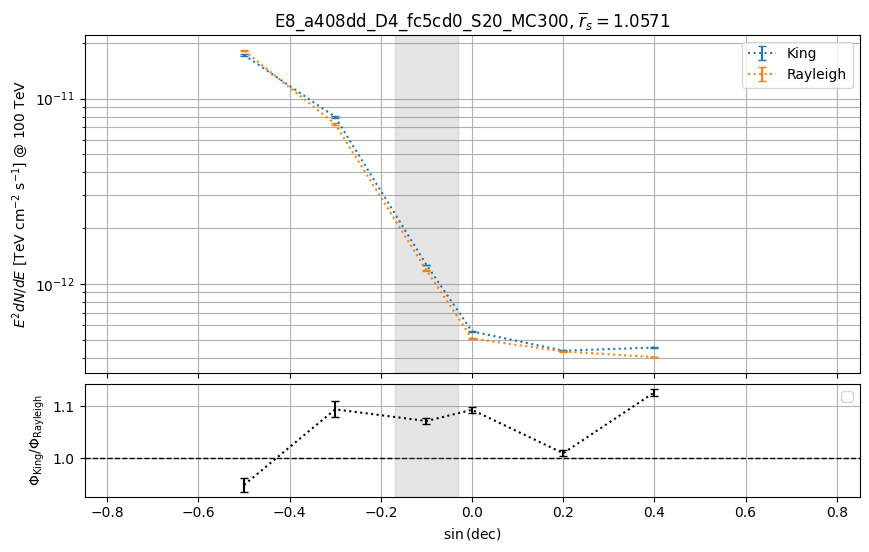

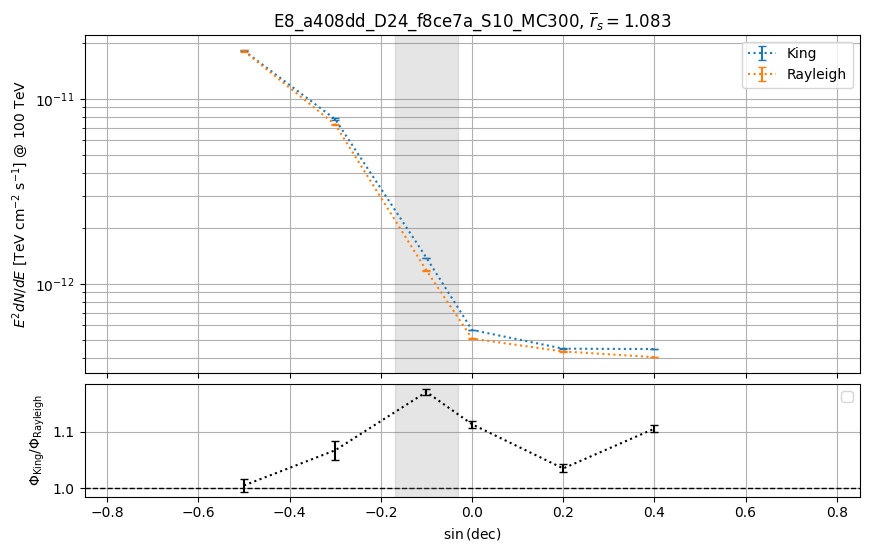

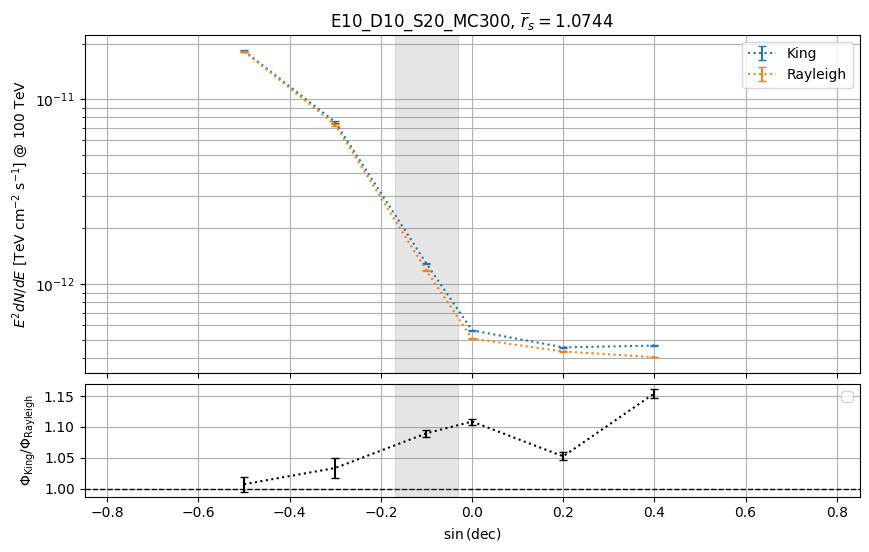

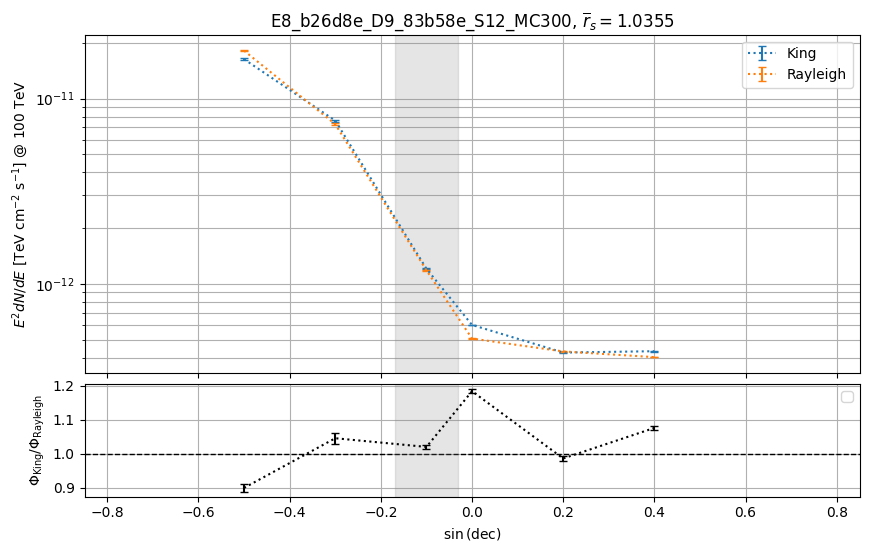

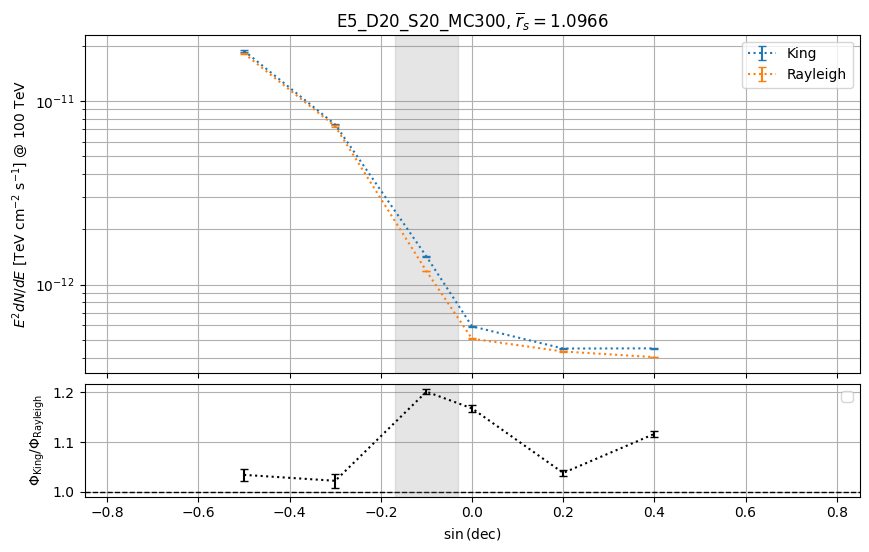

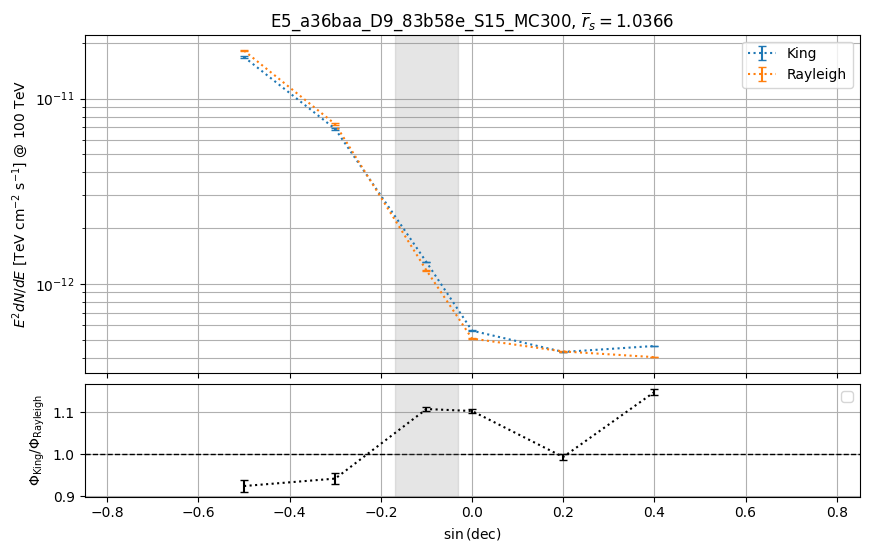

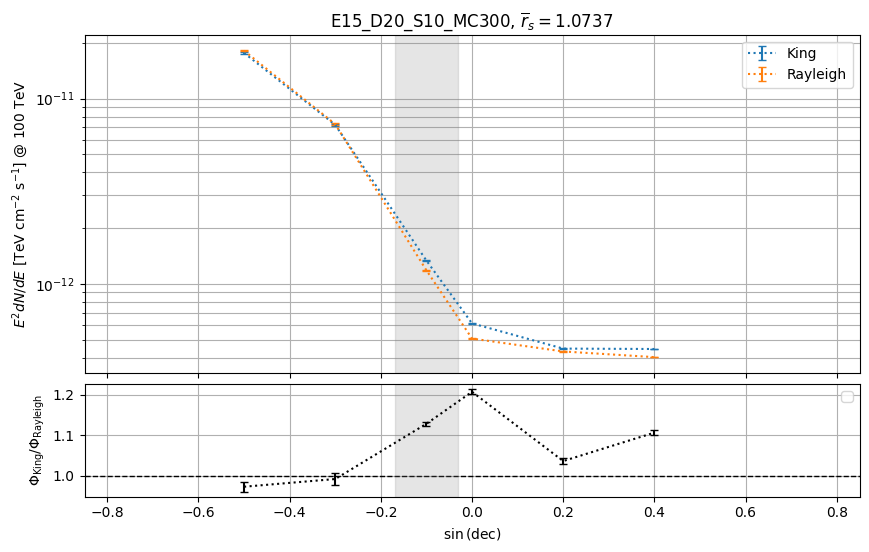

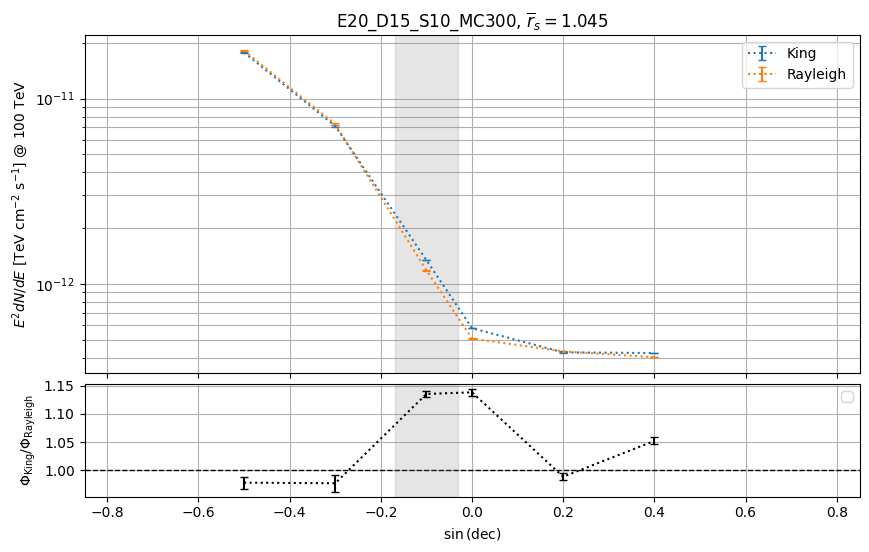

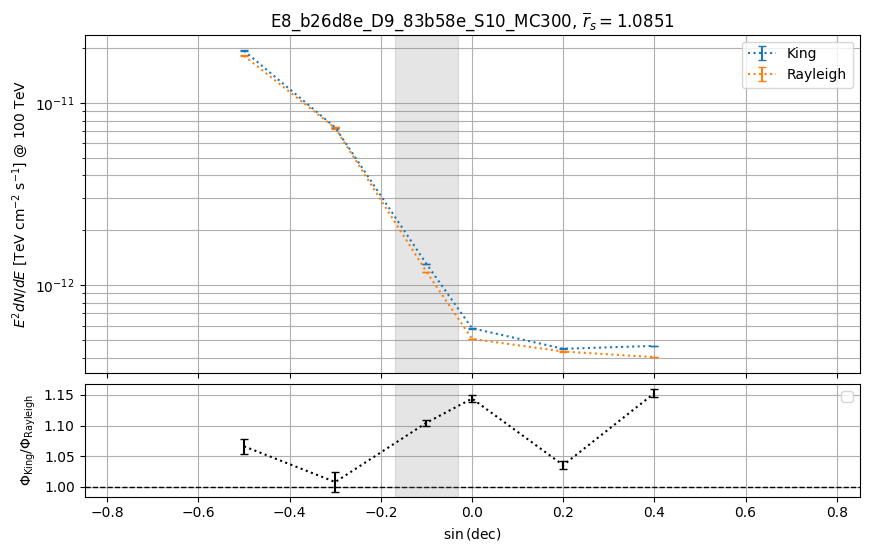

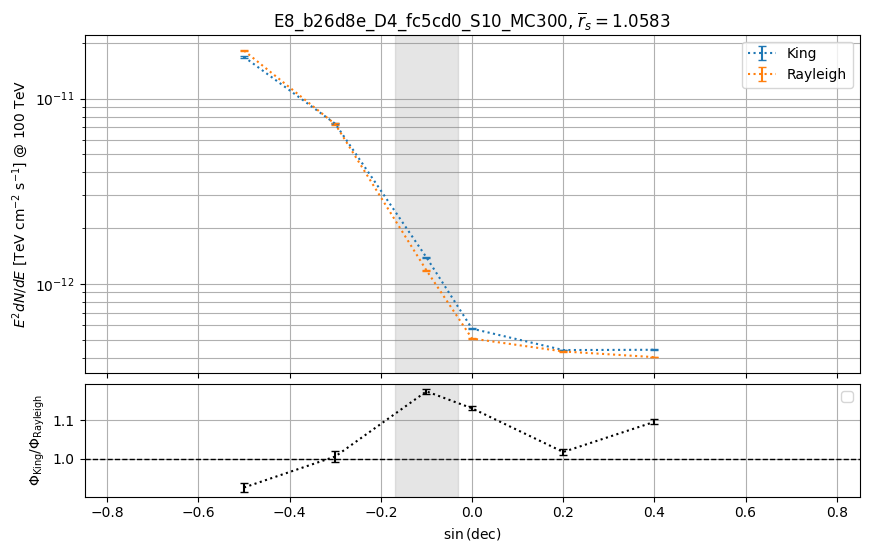

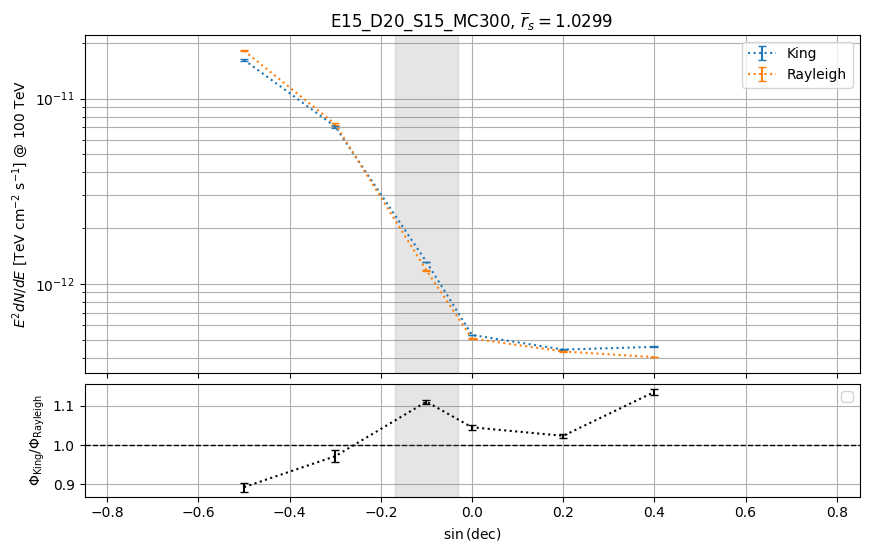

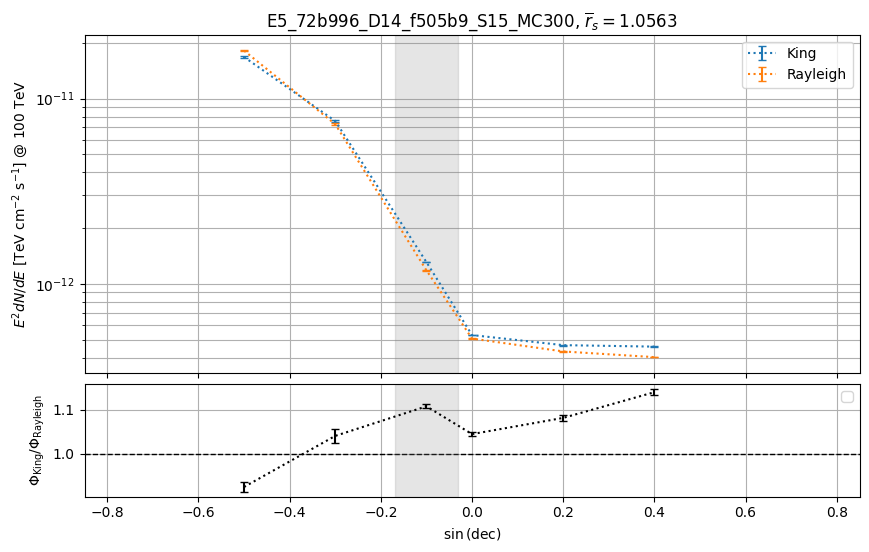

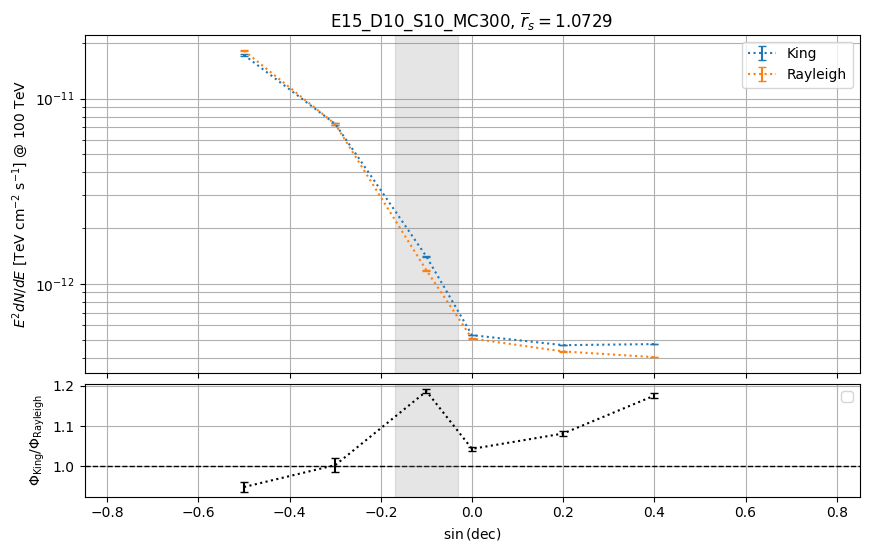

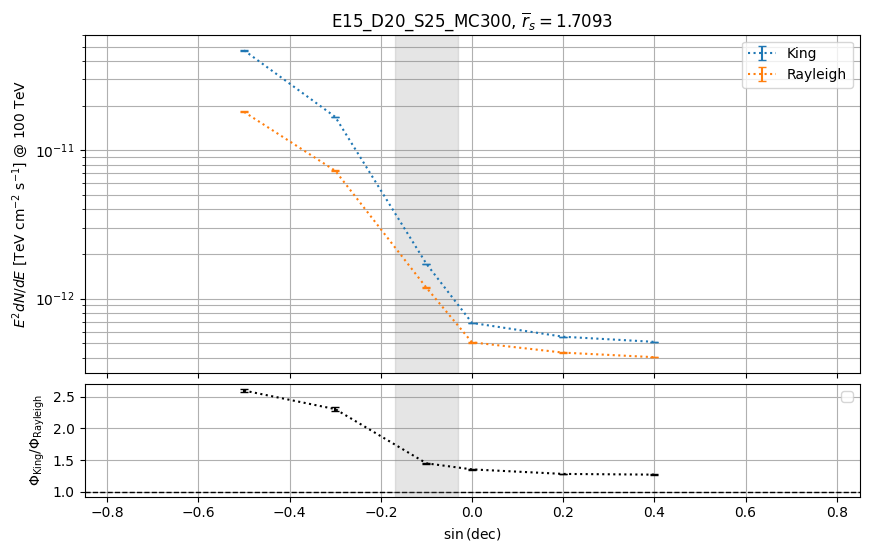

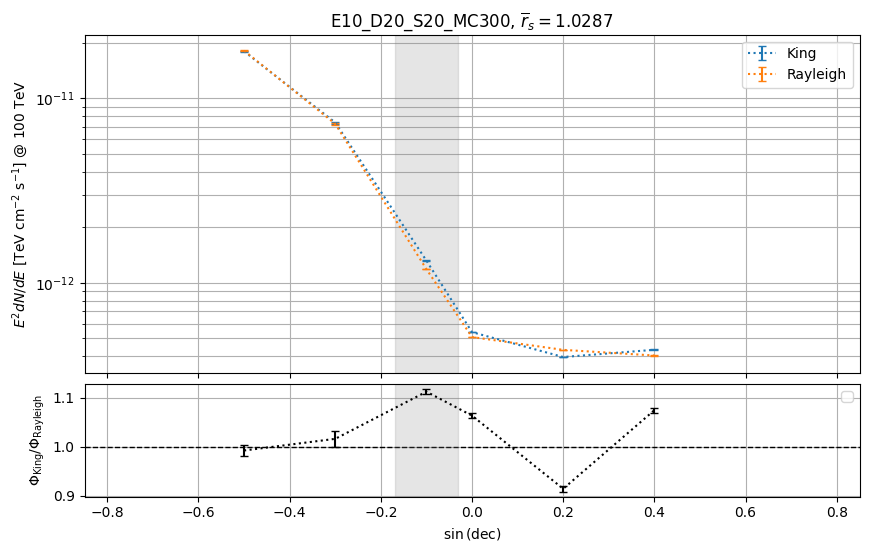

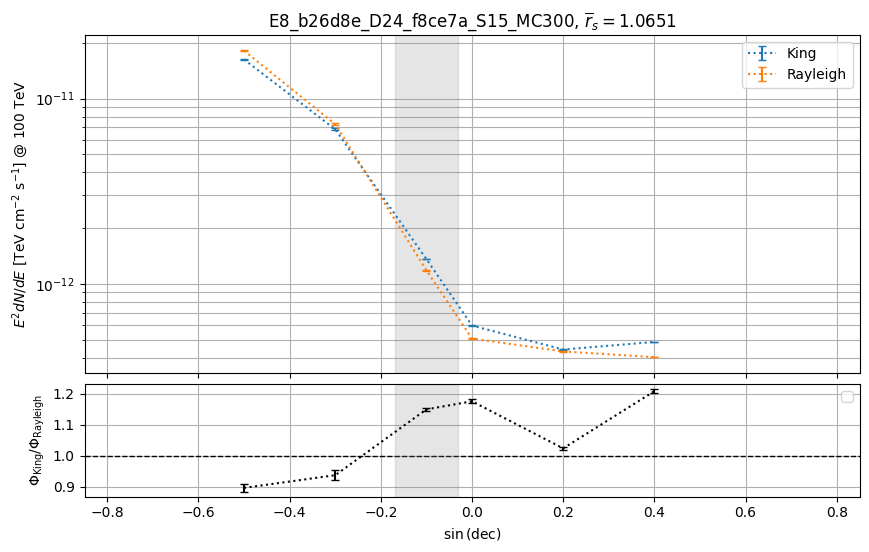

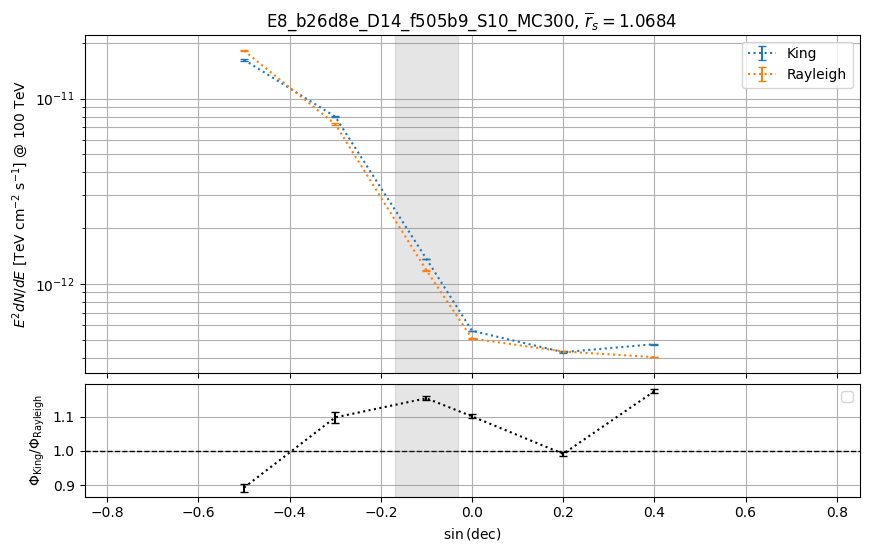

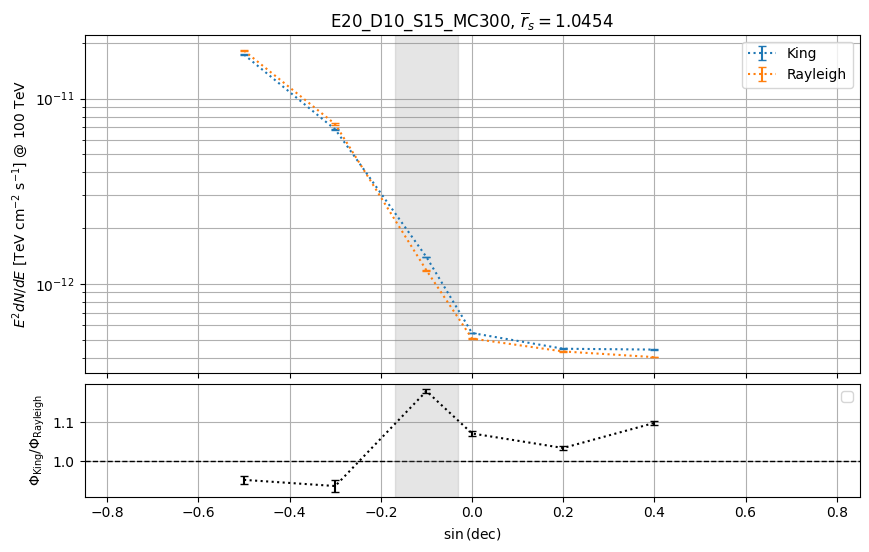

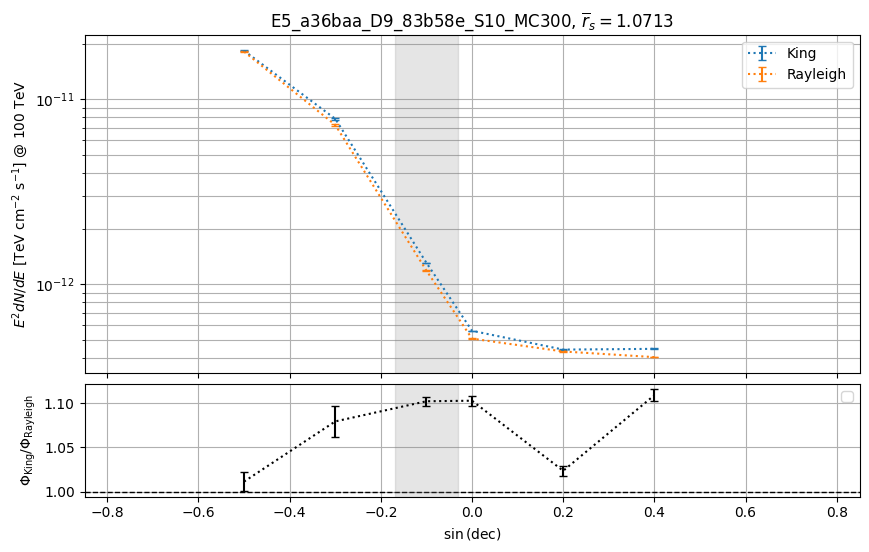

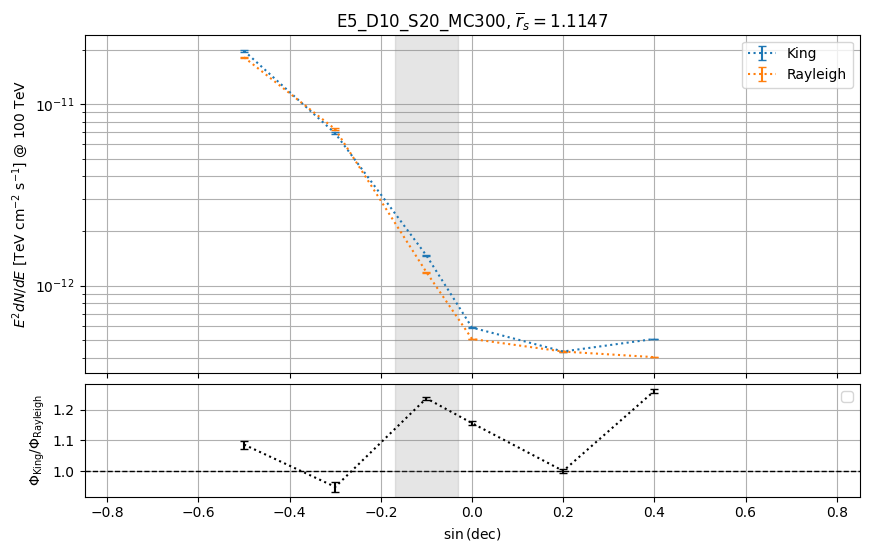

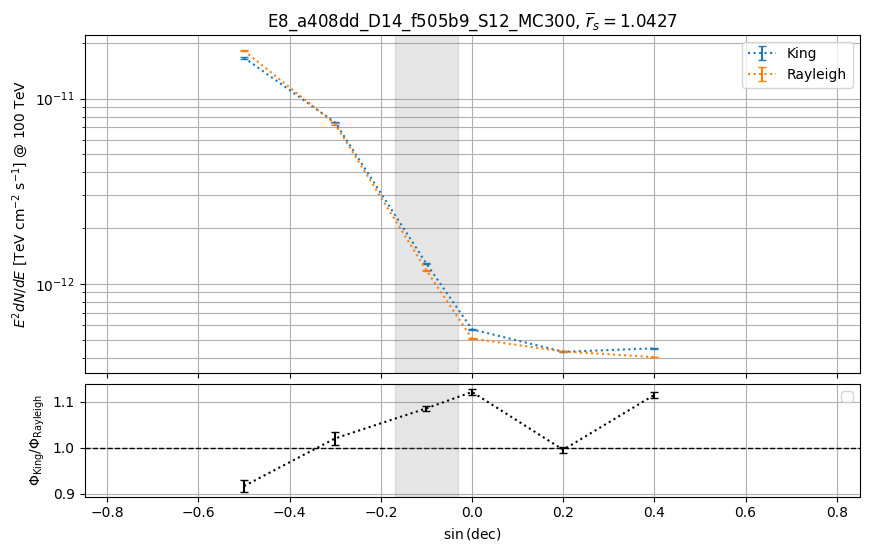

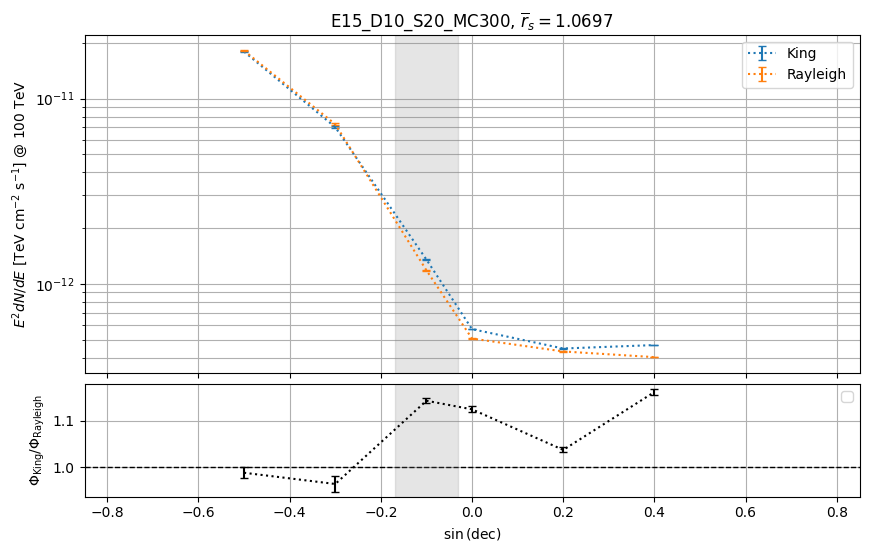

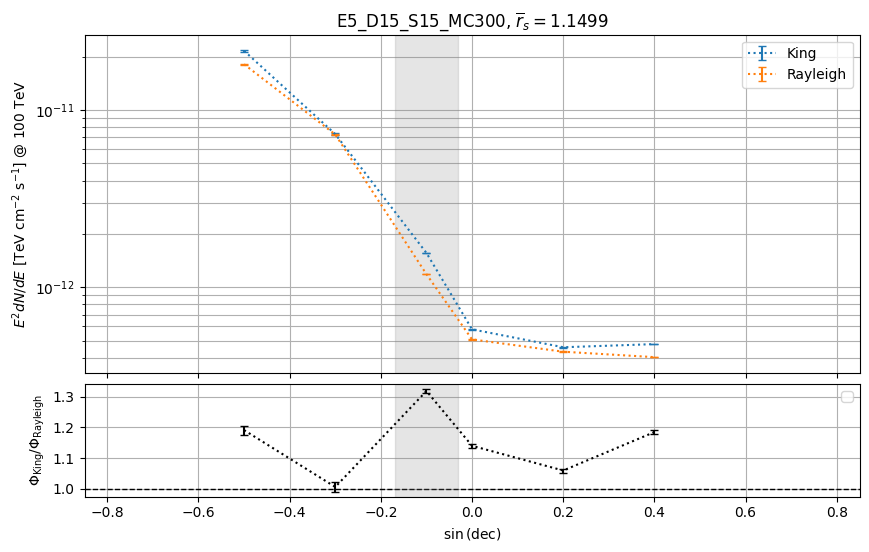

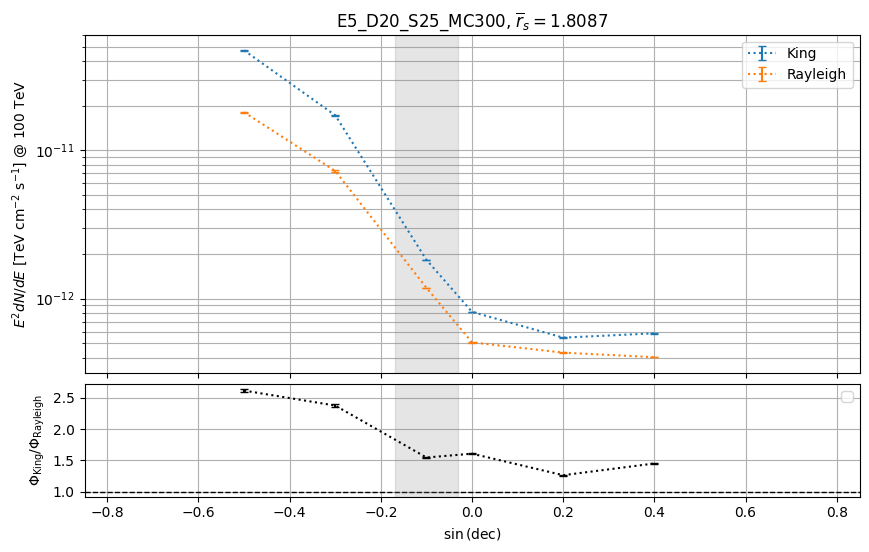

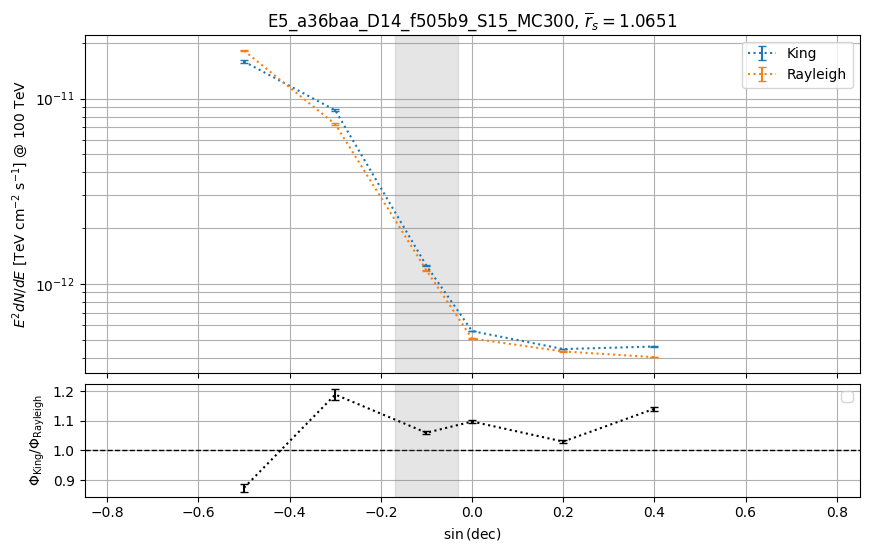

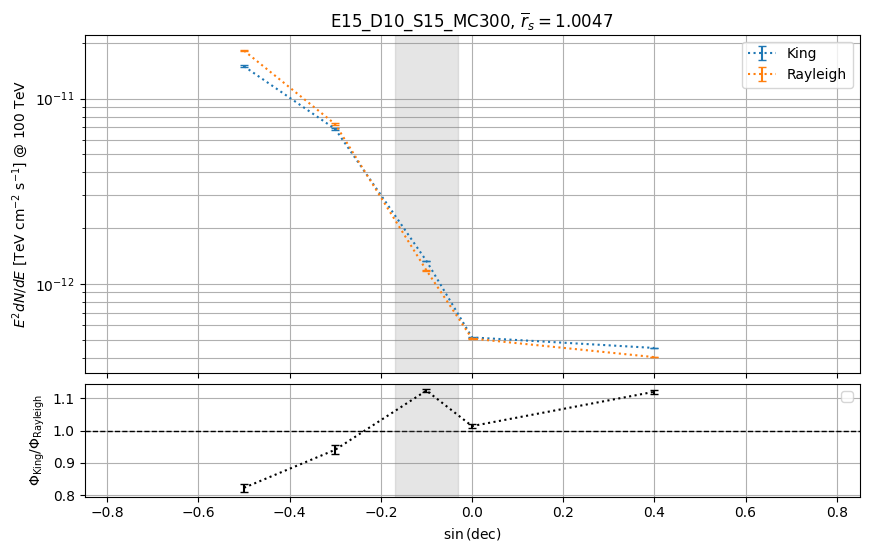

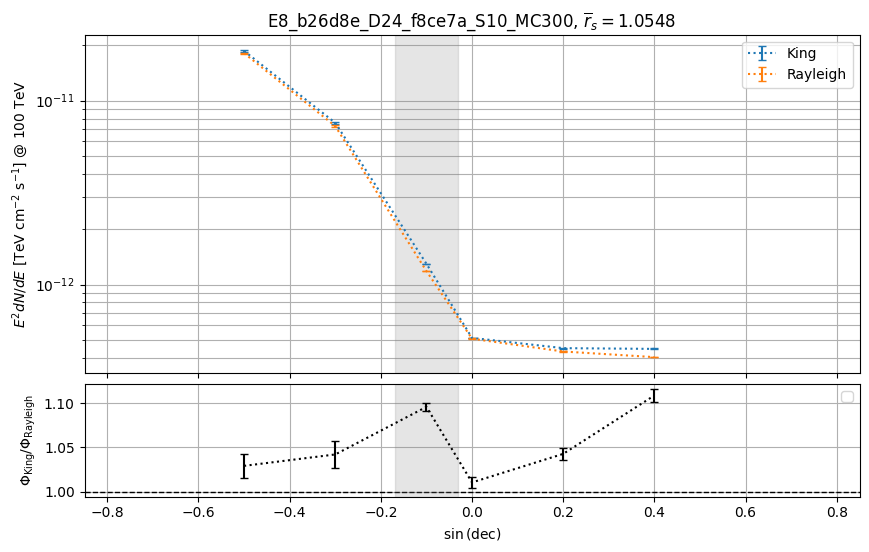

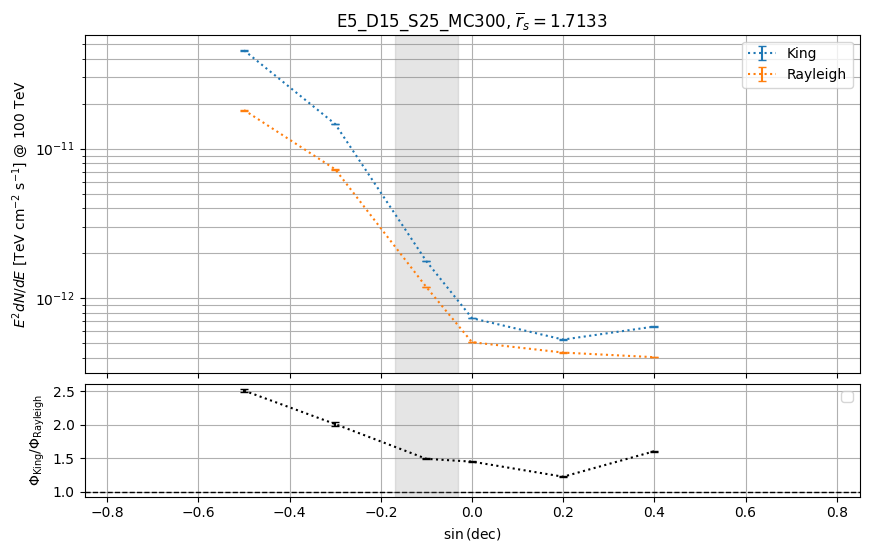

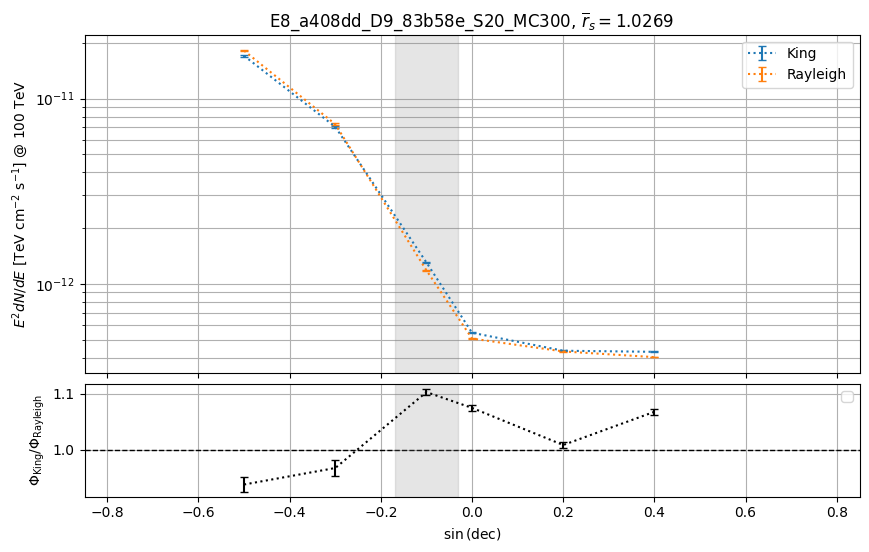

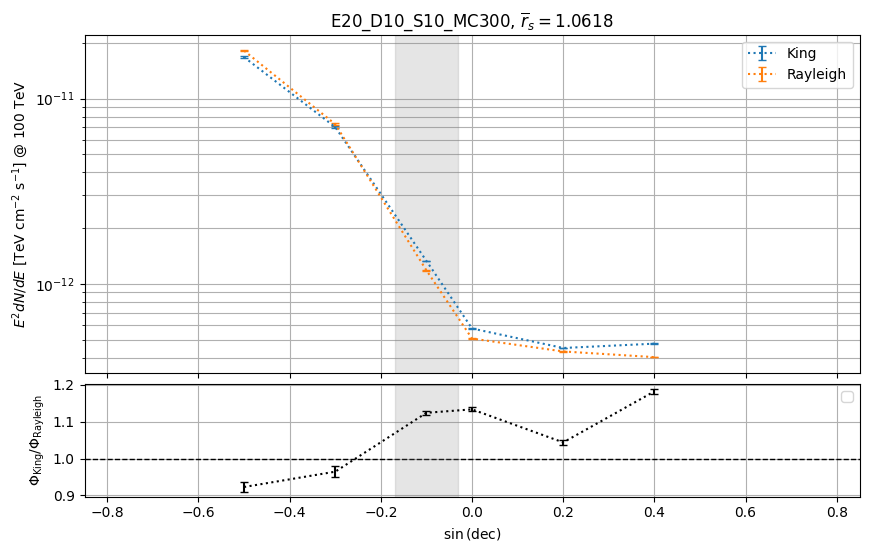

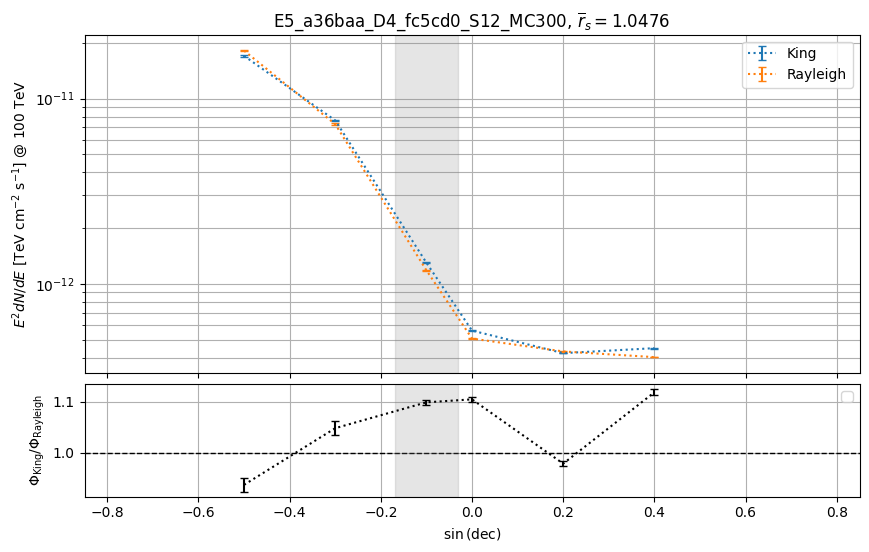

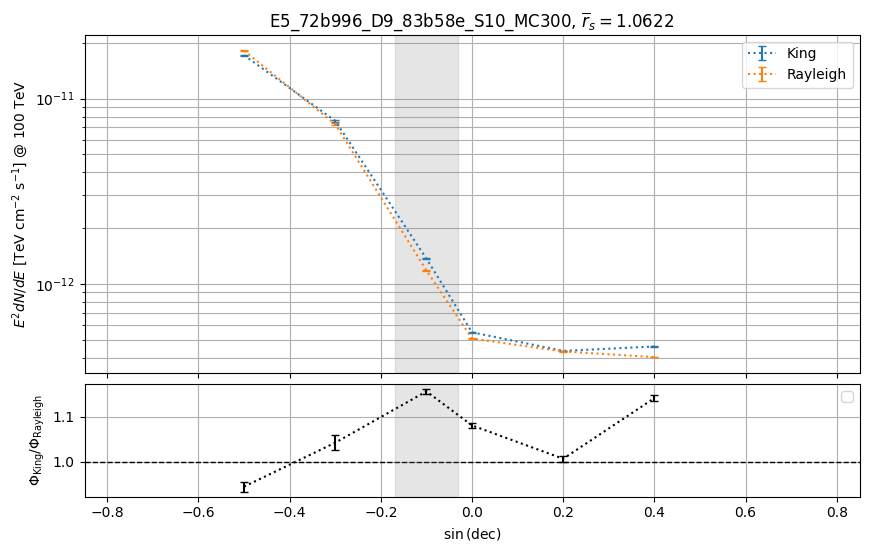

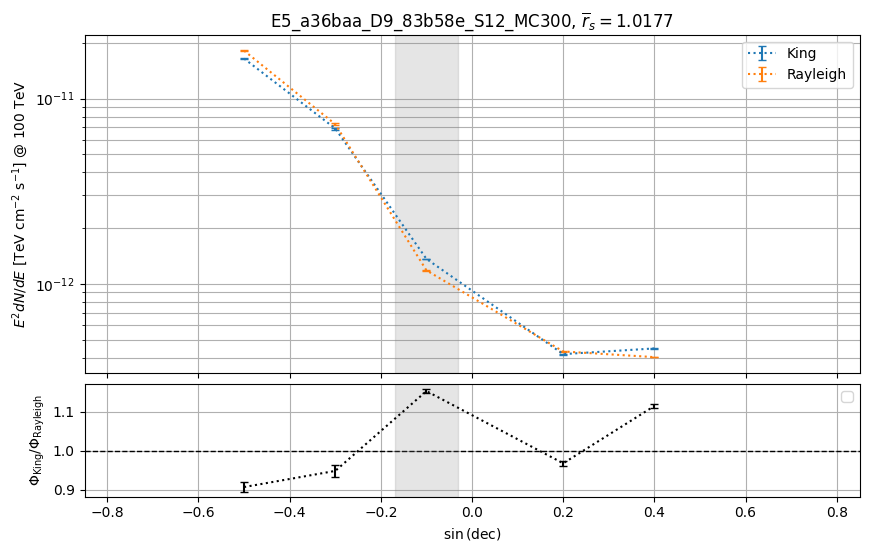

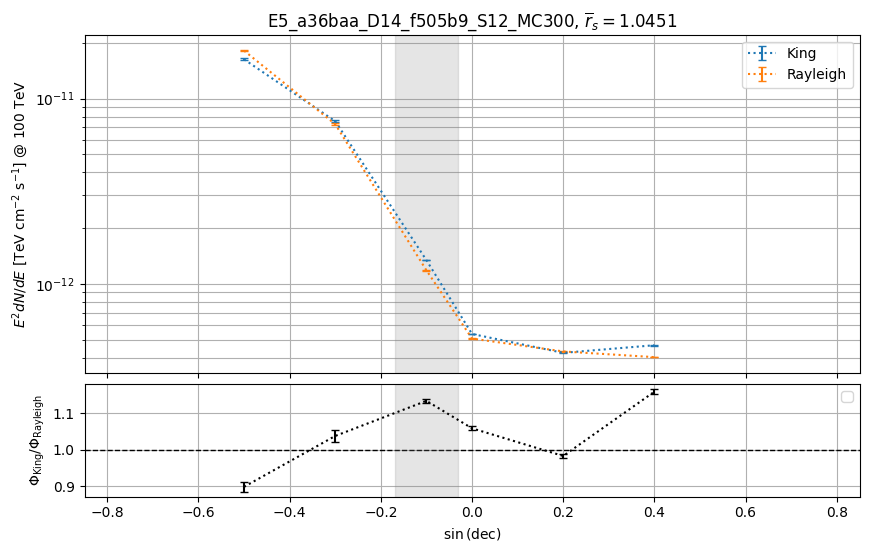

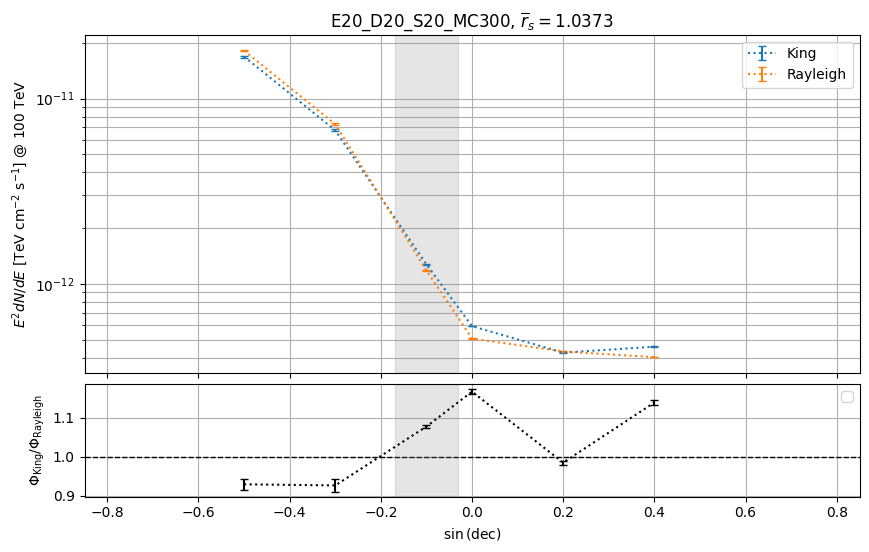

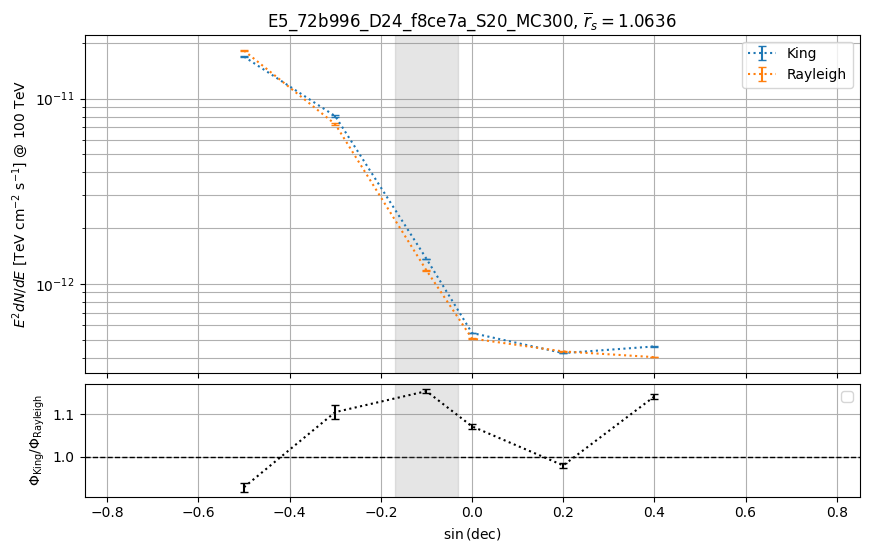

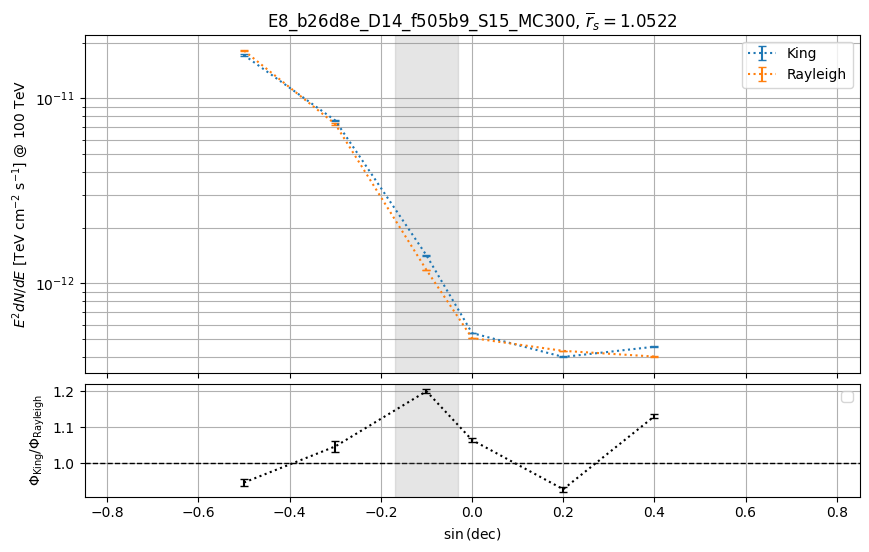

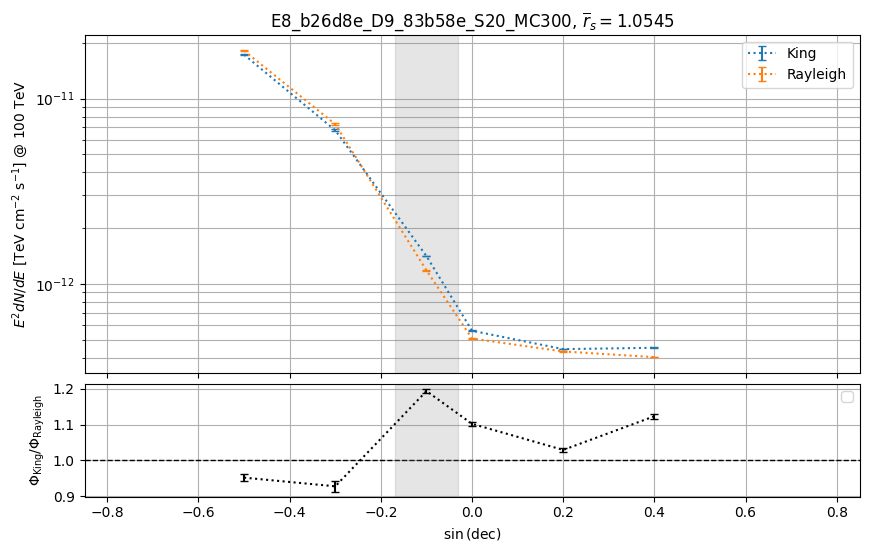

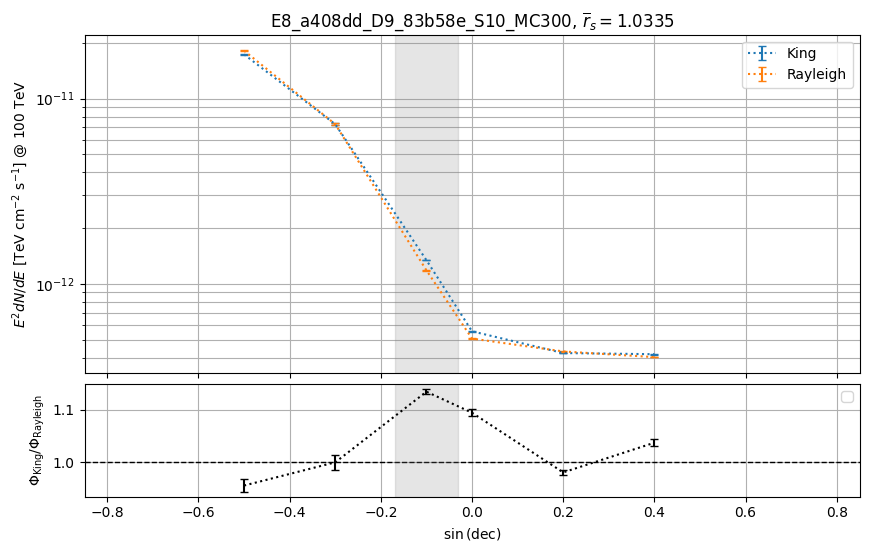

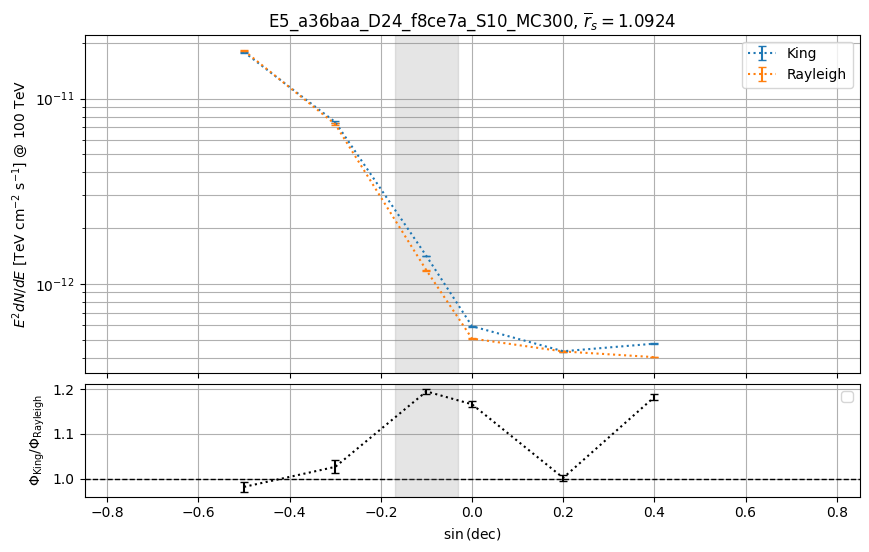

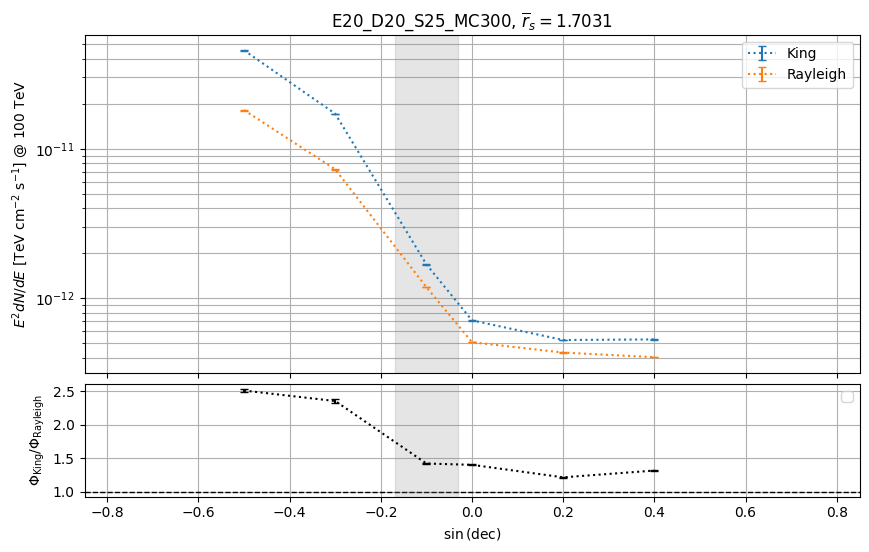

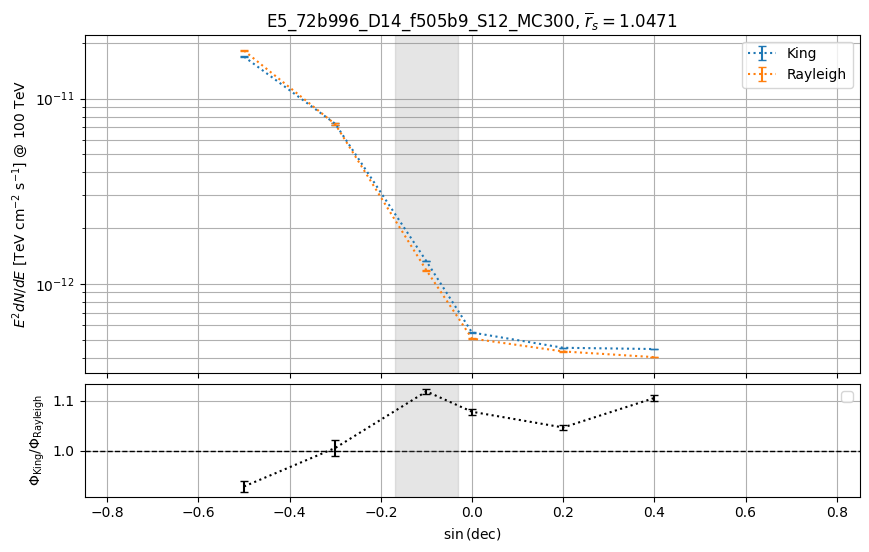

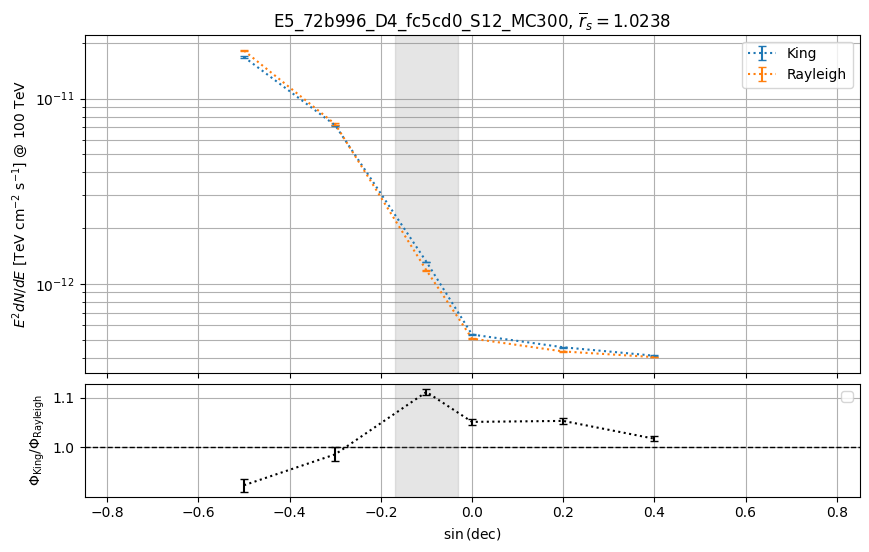

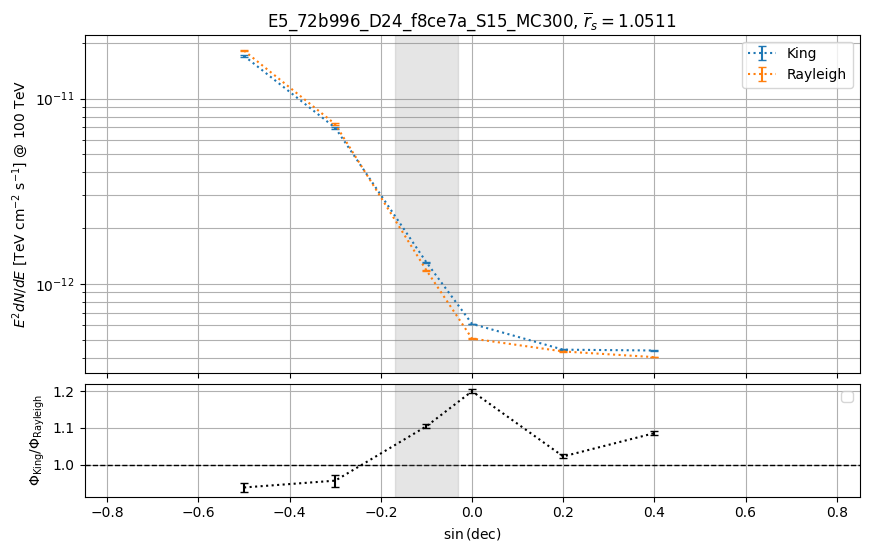

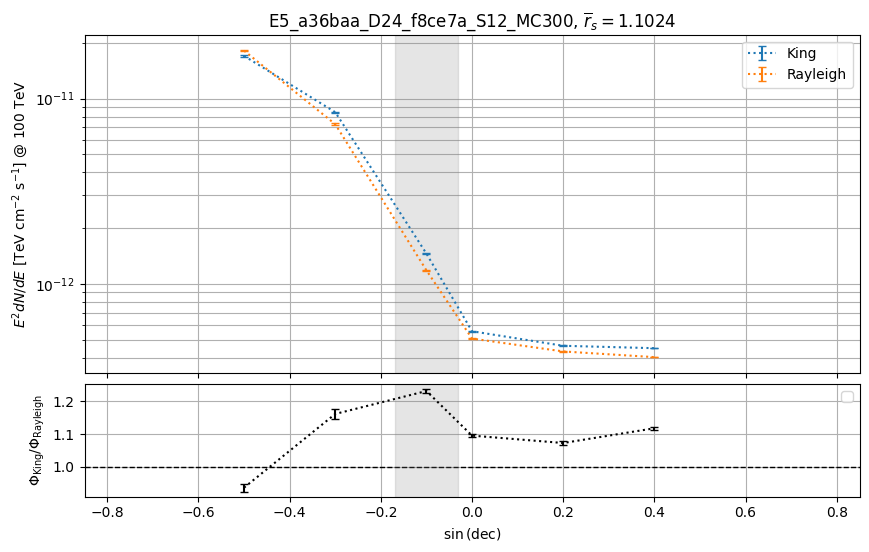

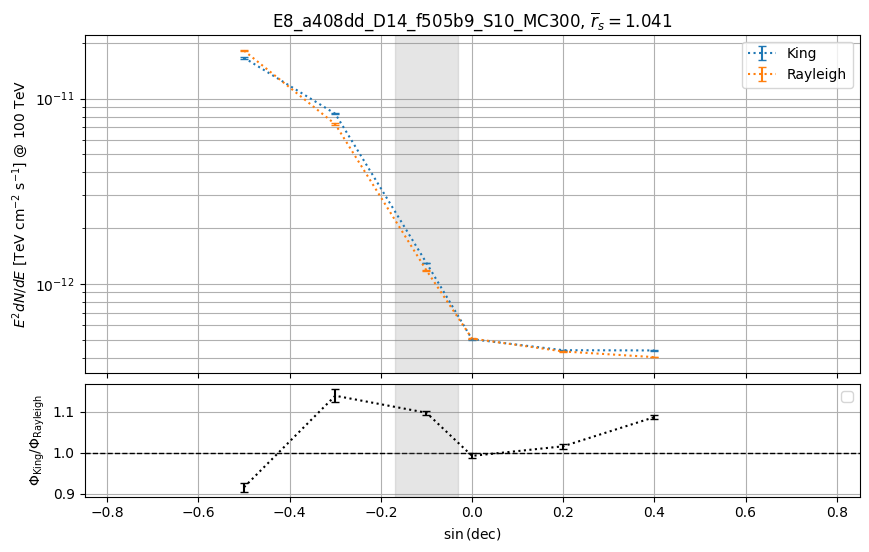

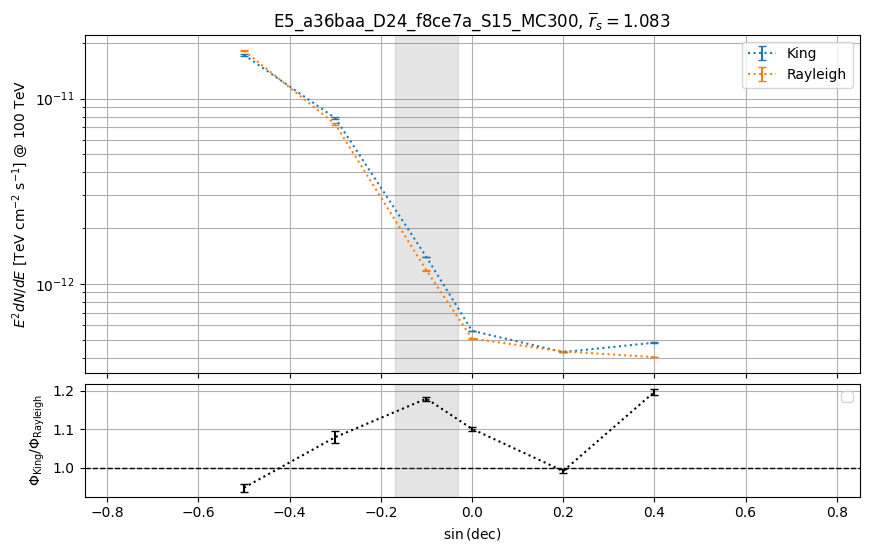

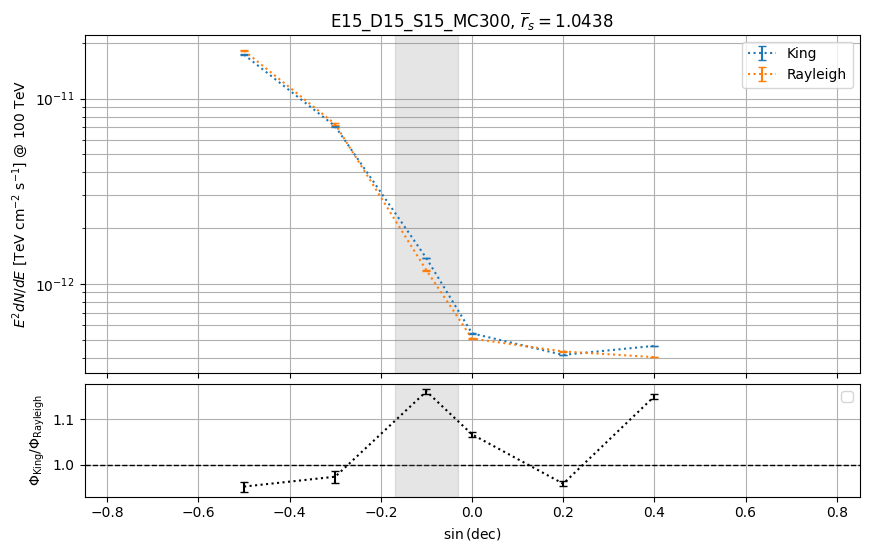

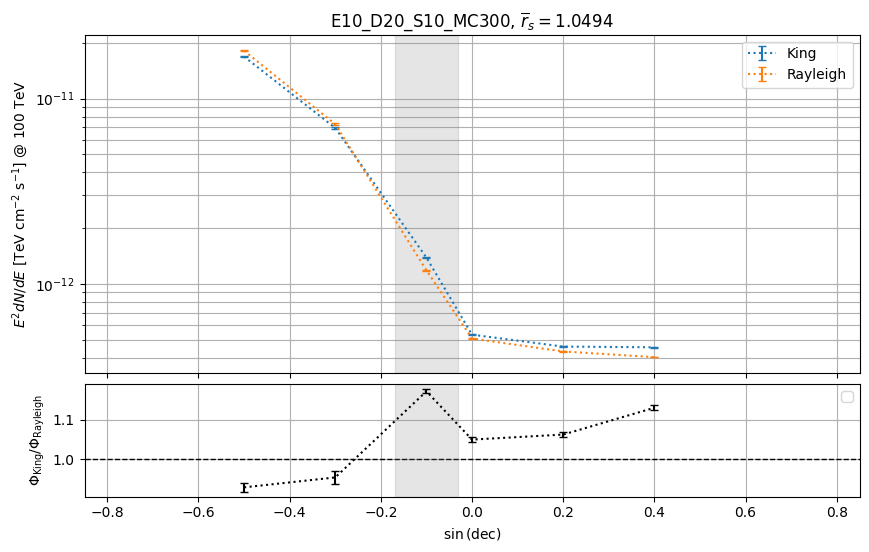

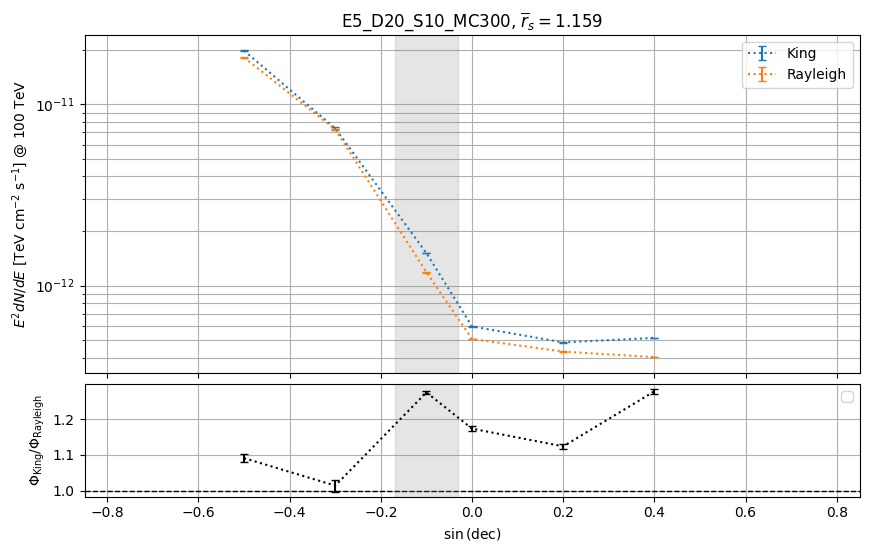

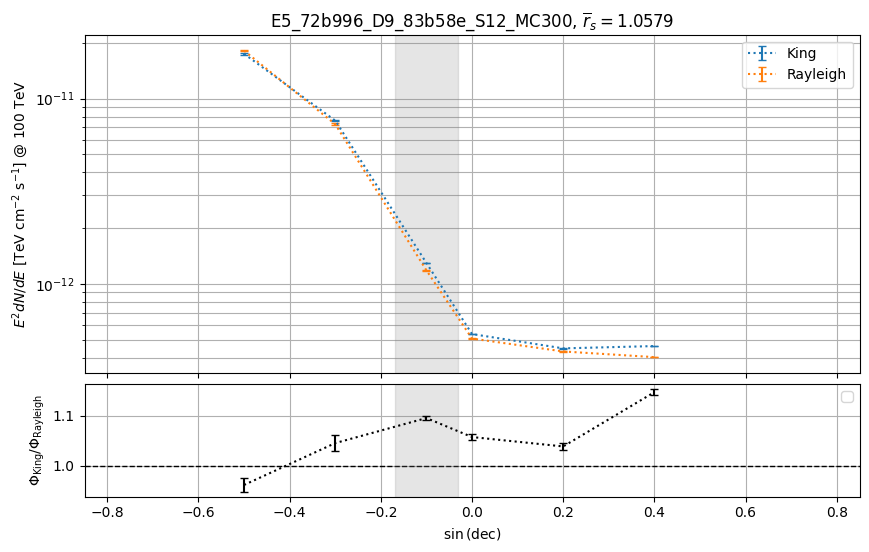

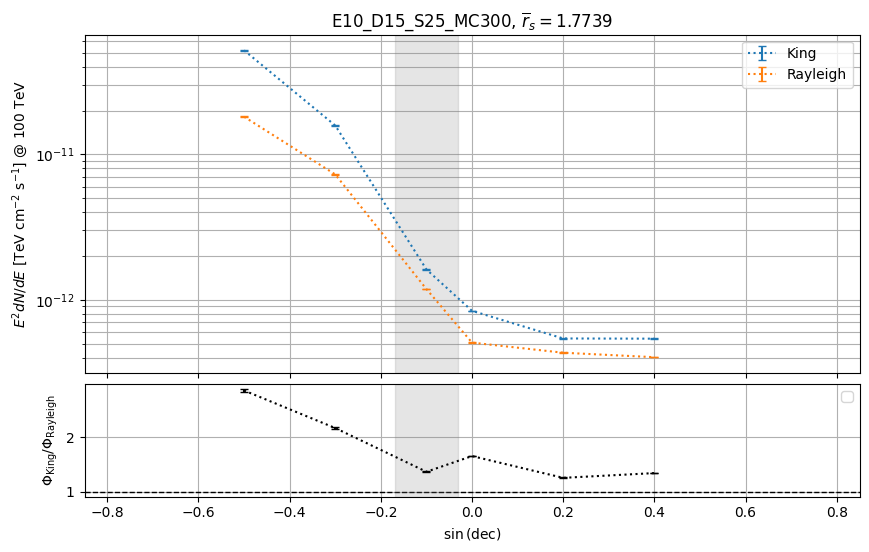

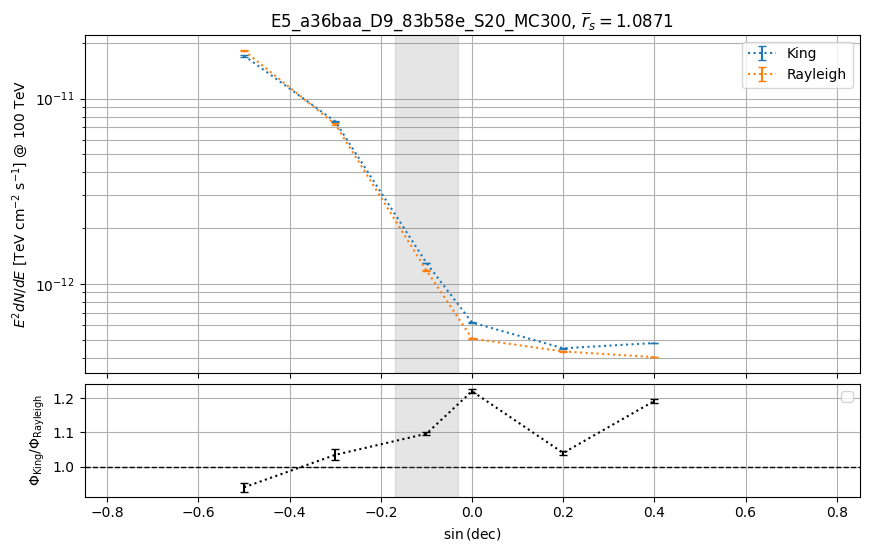

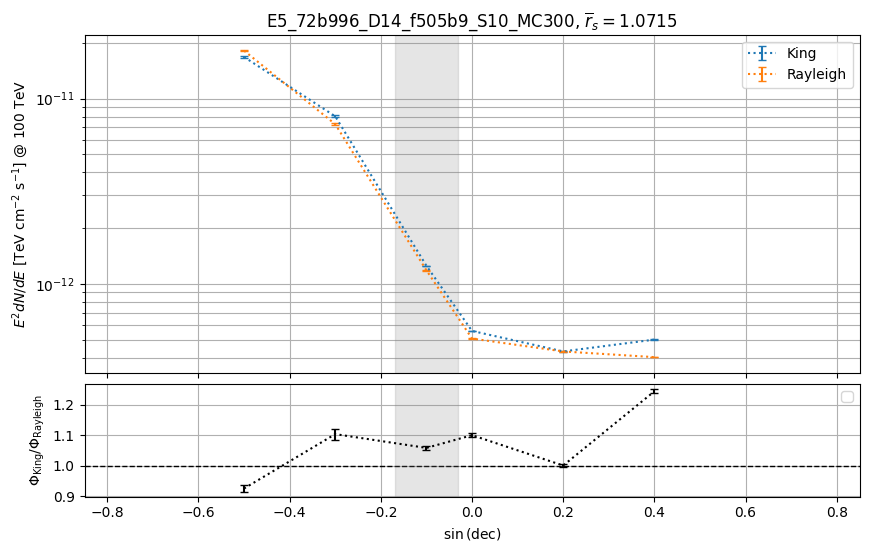

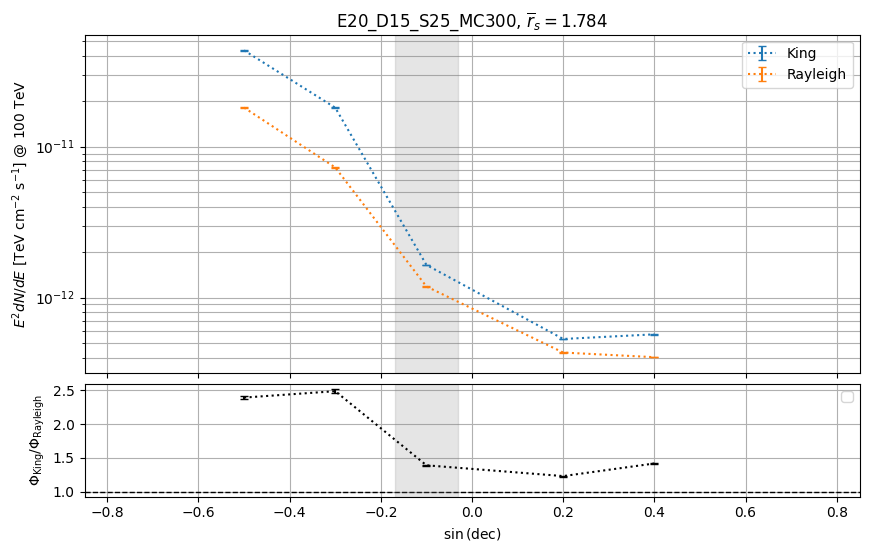

In [33]:
scores = {}
for run in list(king_data.keys()):
    scores[run] = plot_flux(run)

## Analyze Top candidates config and fits

In [36]:
top_scores = []
top_score_names = []
for k, v in scores.items():
    if v < 1.03:
        top_score_names.append(k)
        top_scores.append(v)

In [37]:
top_scores, top_score_names

([1.0097497994000506,
  1.0203725620207313,
  1.0079319511683291,
  1.023253335192527,
  1.0298787093915907,
  1.0287000817549947,
  1.004737648759302,
  1.0269060941475083,
  1.0177072610819637,
  1.0237994969915236],
 ['E8_b26d8e_D24_f8ce7a_S12_MC300',
  'E8_a408dd_D9_83b58e_S15_MC300',
  'E15_D15_S20_MC300',
  'E8_a408dd_D4_fc5cd0_S12_MC300',
  'E15_D20_S15_MC300',
  'E10_D20_S20_MC300',
  'E15_D10_S15_MC300',
  'E8_a408dd_D9_83b58e_S20_MC300',
  'E5_a36baa_D9_83b58e_S12_MC300',
  'E5_72b996_D4_fc5cd0_S12_MC300'])

In [38]:
king_data['E8_b26d8e_D24_f8ce7a_S12_MC300']['parametrization_bins']

KeyError: 'parametrization_bins'

### sensitivity

/tmp/ipykernel_1712625/40256637.py:113: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax_diff.legend()


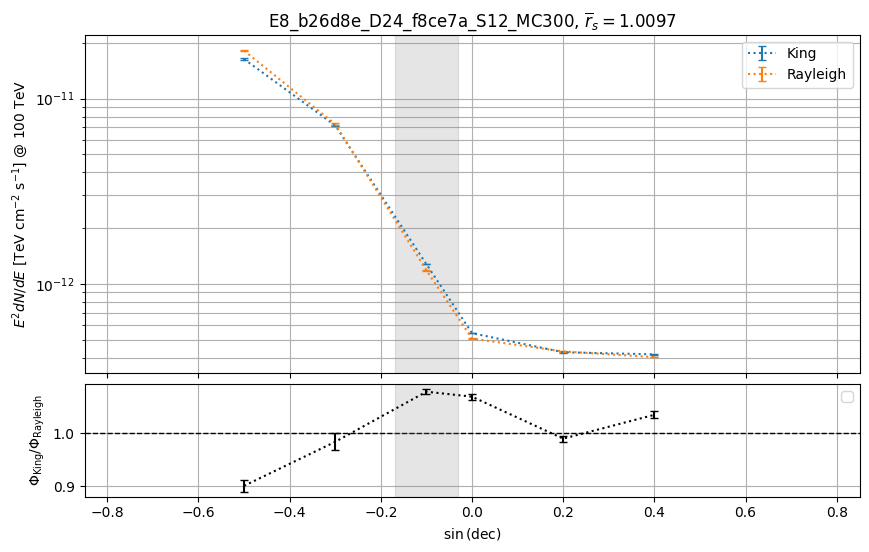

{'log10energy': array([ 2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ,  6. , 10. ]), 'dec': array([-1.57079633, -1.15965847, -0.98511078, -0.84806208, -0.72972766,
       -0.62282658, -0.52359878, -0.42977543, -0.33983691, -0.25268026,
       -0.16744808, -0.08343008,  0.        ,  0.08343008,  0.16744808,
        0.25268026,  0.33983691,  0.42977543,  0.52359878,  0.62282658,
        0.72972766,  0.84806208,  0.98511078,  1.15965847,  1.57079633]), 'sigma': array(12)}


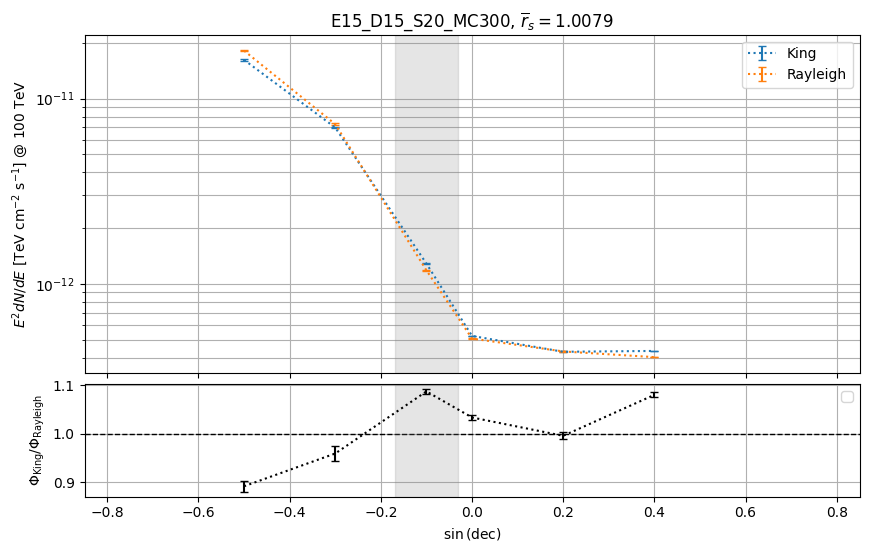

{'log10energy': array(15), 'dec': array(15), 'sigma': array(20)}


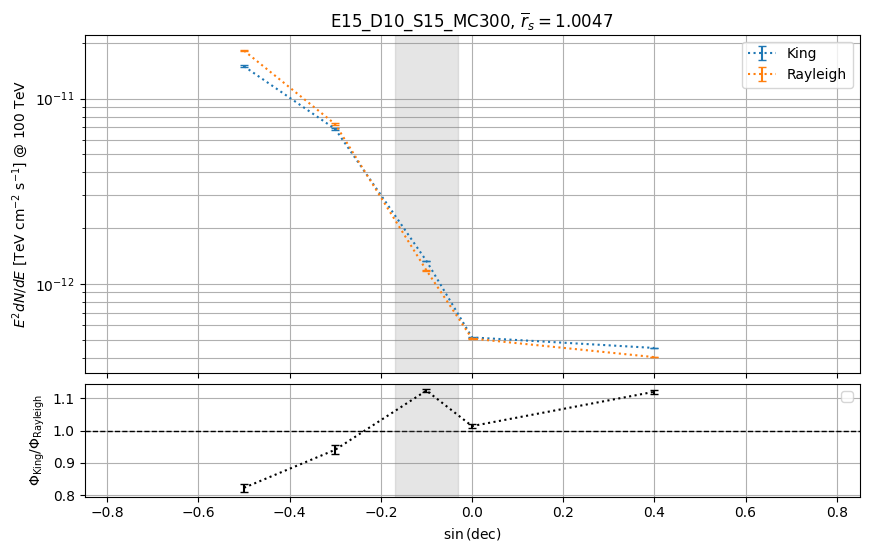

{'log10energy': array(15), 'dec': array(10), 'sigma': array(15)}


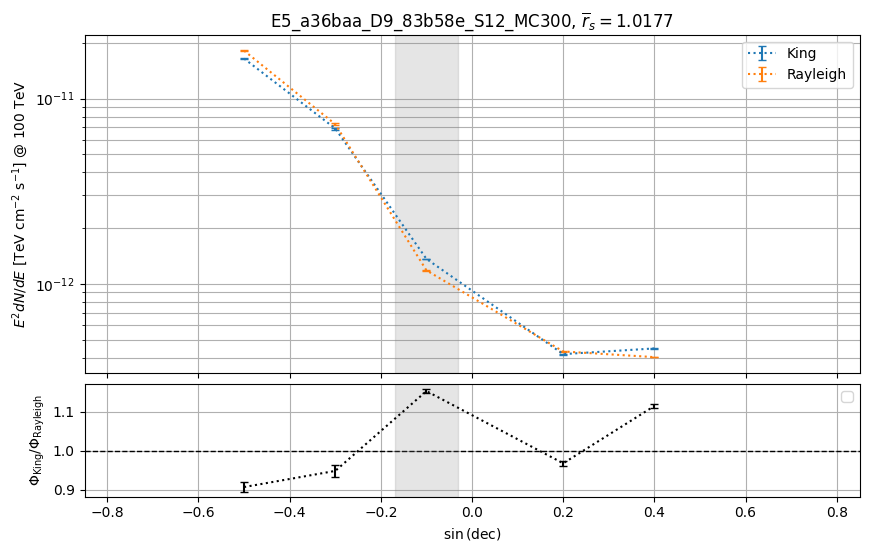

{'log10energy': array([ 2.  ,  2.5 ,  3.25,  4.25,  6.  , 10.  ]), 'dec': array([-1.57079633, -0.89112251, -0.58903098, -0.33983691, -0.11134101,
        0.11134101,  0.33983691,  0.58903098,  0.89112251,  1.57079633]), 'sigma': array(12)}


: 

In [ ]:
for name in top_score_names:
    plot_flux(name)
    print(get_binning_from_path(os.path.join(run_folder, name)))
    

### showcase fitting

In [4]:
#get cached fits:
fitting_candidate = 'E5_a36baa_D9_83b58e_S12_MC300'
fitting_candidate_sin_dec = 0.2
candidate_id = f"SINDEC_{fitting_candidate_sin_dec}_NTRIALS_{1000}_{fitting_candidate}"
config_dir = os.path.join(run_folder, fitting_candidate, f"king_trial_runner_config_sindec_{fitting_candidate_sin_dec}_{candidate_id}.pkl")

In [8]:
plot_flux(fitting_candidate, show_title= False)

NameError: name 'plot_flux' is not defined

In [5]:


with open(config_dir, "rb") as f:
        cfg = pickle.load(f)
out_dir = os.path.join(run_folder, fitting_candidate)
fit_cache_path = os.path.join(out_dir, cfg["fit_cache_filename"])
repo_cache = cy.utils.ensure_dir('/data/user/fkrafft/csky_repo')
repo = cy.selections.Repository(
    local_root= repo_cache,
    remote_root= '/data/ana/PointSource/GFU/online_v001-p10')

ana_dir = cy.utils.ensure_dir('/data/user/fkrafft/csky_gfu_tests')

ana = cy.get_analysis(repo, 'version-001-p09' , custom_gfu.gfu_19_to_23, dir = ana_dir)

tr, king_wrapper, king_func, cfg= restore_king_trial_runner(
        config_path=  config_dir,
        ana = ana
        )


Setting up Analysis for:
GFU_2019_2023
Setting up GFU_2019_2023...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2023_MC.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2022_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2022_data.npy ...
Energy PDF Ratio Model...
  * gamma = 4.0000 ...
Signal Acceptance Model...
  * gamma = 4.0000 ...
not applying any masking
Done.
NOTE: 

#### fitting param space heatmaps

In [10]:
fit_parameters = king_wrapper.fitted_parameters
gamma_idx = 1
alpha_vals = fit_parameters["alpha"][gamma_idx]
beta_vals = fit_parameters["beta"][gamma_idx]
event_counts = fit_parameters["event_counts"][gamma_idx]
fit_quality_chi2 = fit_parameters["fit_quality"][gamma_idx]


In [12]:
fit_parameters['parametrization_bins']

array({'log10energy': array([ 2.  ,  2.5 ,  3.25,  4.25,  6.  , 10.  ]), 'dec': array([-1.57079633, -0.89112251, -0.58903098, -0.33983691, -0.11134101,
        0.11134101,  0.33983691,  0.58903098,  0.89112251,  1.57079633]), 'sigma': array([0.00349066, 0.0047325 , 0.00650461, 0.00809006, 0.00976703,
       0.01165397, 0.01386859, 0.01656322, 0.01997425, 0.02454972,
       0.03131175, 0.0438294 , 1.1385913 ], dtype=float32)}, dtype=object)

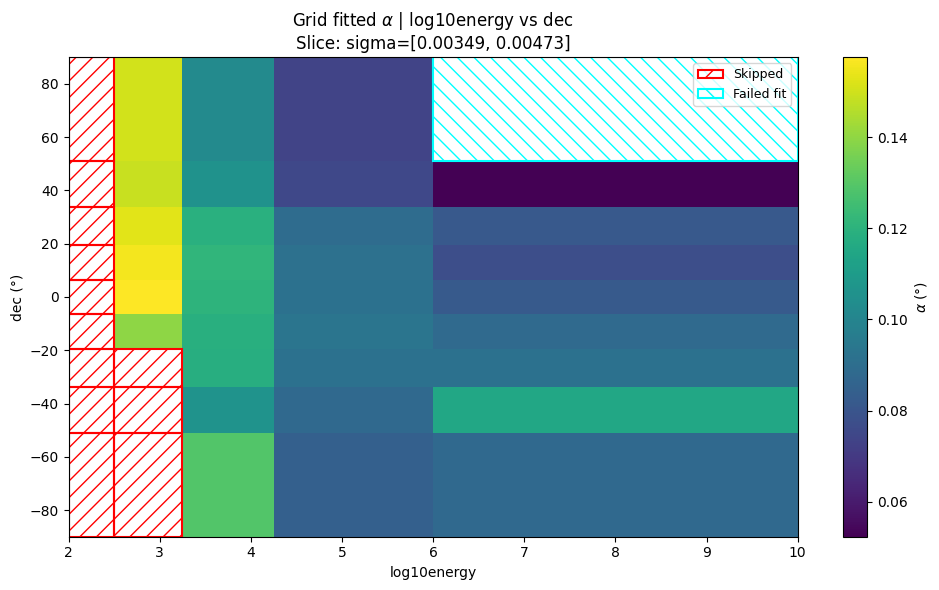

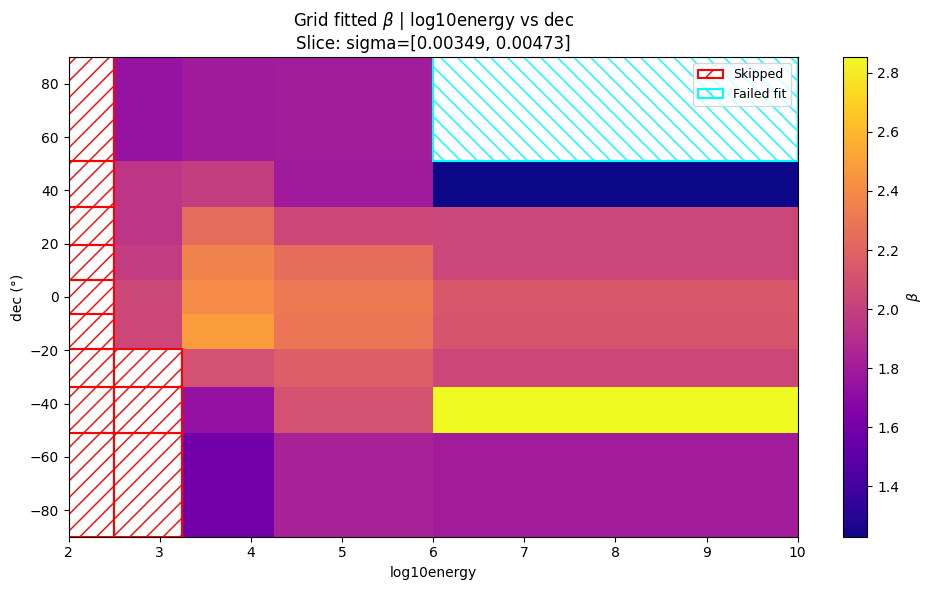

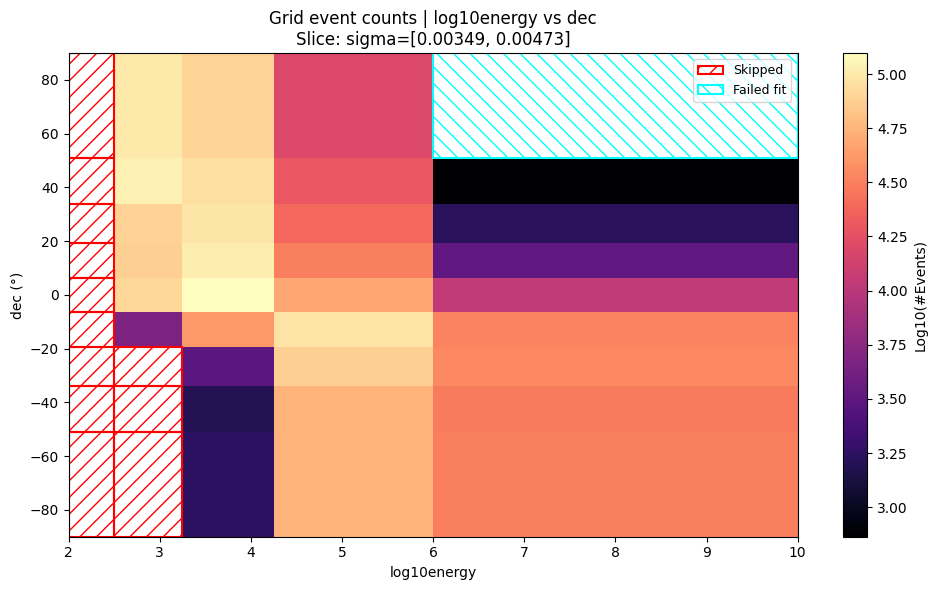

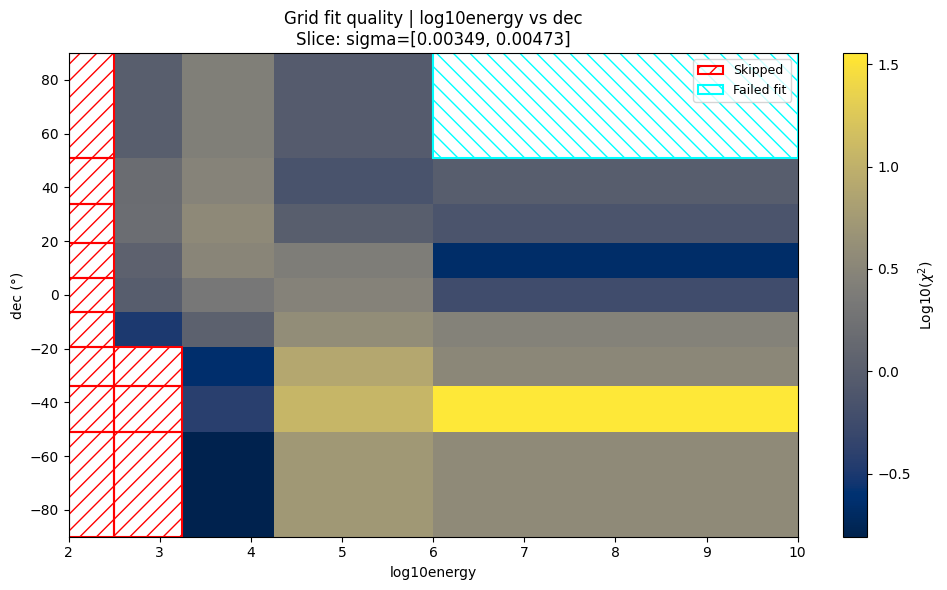

<Axes: title={'center': 'Grid fit quality | log10energy vs dec\nSlice: sigma=[0.00349, 0.00473]'}, xlabel='log10energy', ylabel='dec (°)'>

In [11]:
hidden_value = np.deg2rad(0.1)
angerr_bins = fit_parameters["parametrization_bins"].item()["sigma"]

angerr_idx = np.digitize(hidden_value, angerr_bins) - 1
angerr_idx = np.clip(angerr_idx, 0, len(angerr_bins) - 2)

hidden_slices = {"sigma": angerr_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | log10energy vs dec",
    cbar_label="$\\alpha$ (°)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=beta_vals,
    title="Grid fitted $\\beta$ | log10energy vs dec",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    log_values= True,
    y_name="dec",
    values=event_counts,
    title="Grid event counts | log10energy vs dec",
    cbar_label="Log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    hidden_slices=hidden_slices,
)
fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="dec",
    values=fit_quality_chi2,
    title="Grid fit quality | log10energy vs dec",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    hidden_slices=hidden_slices,
)

In [ ]:
np.rad2deg(-0.1)

-5.729577951308233

: 

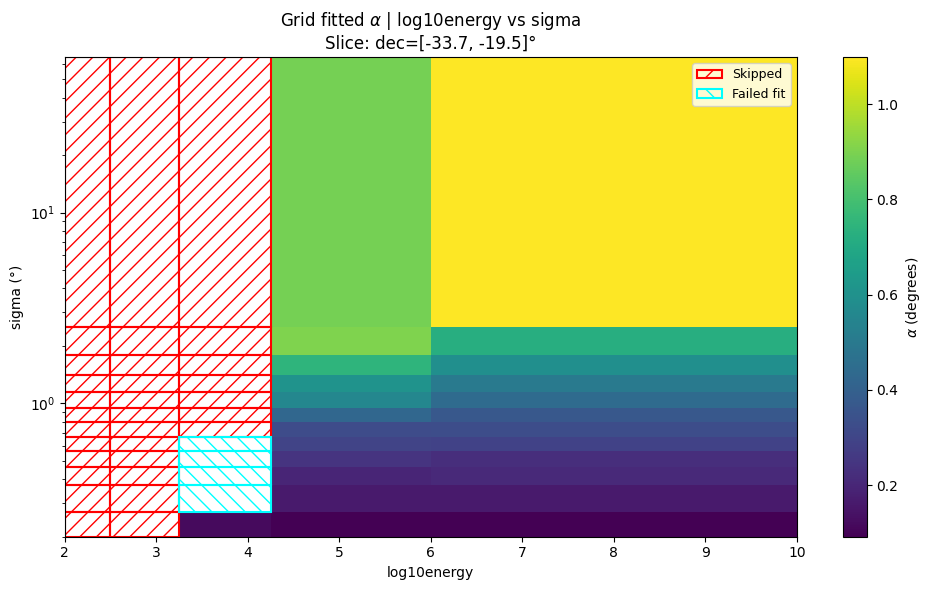

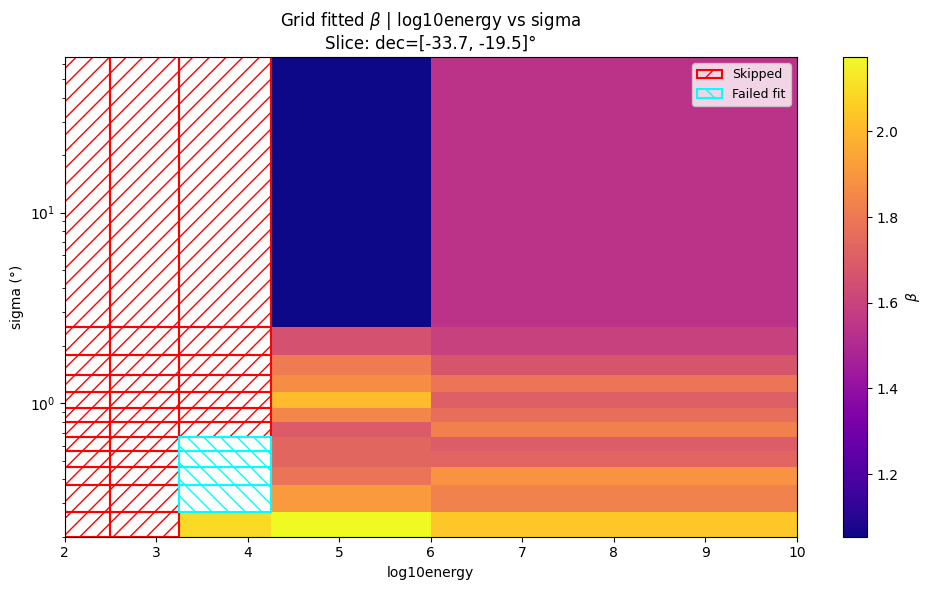

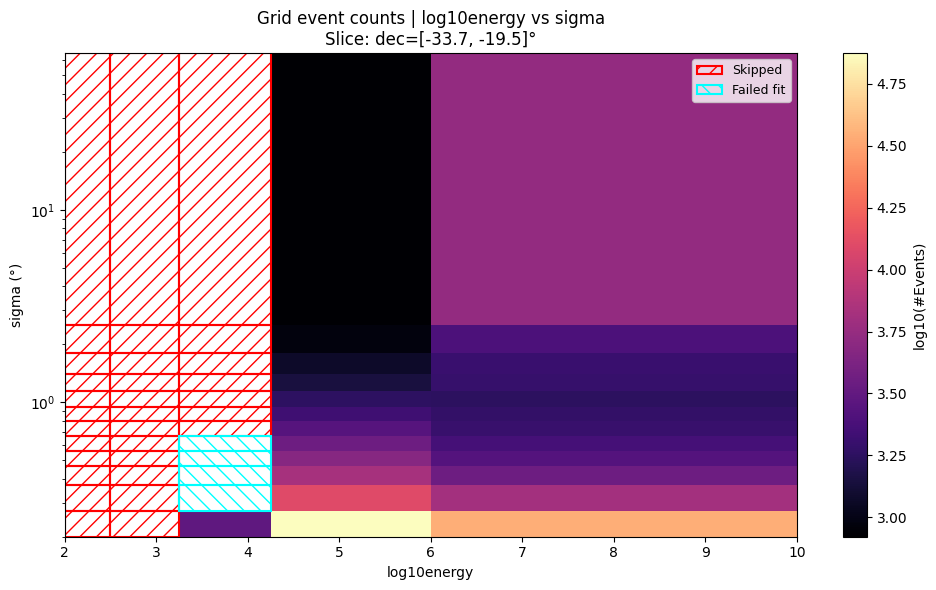

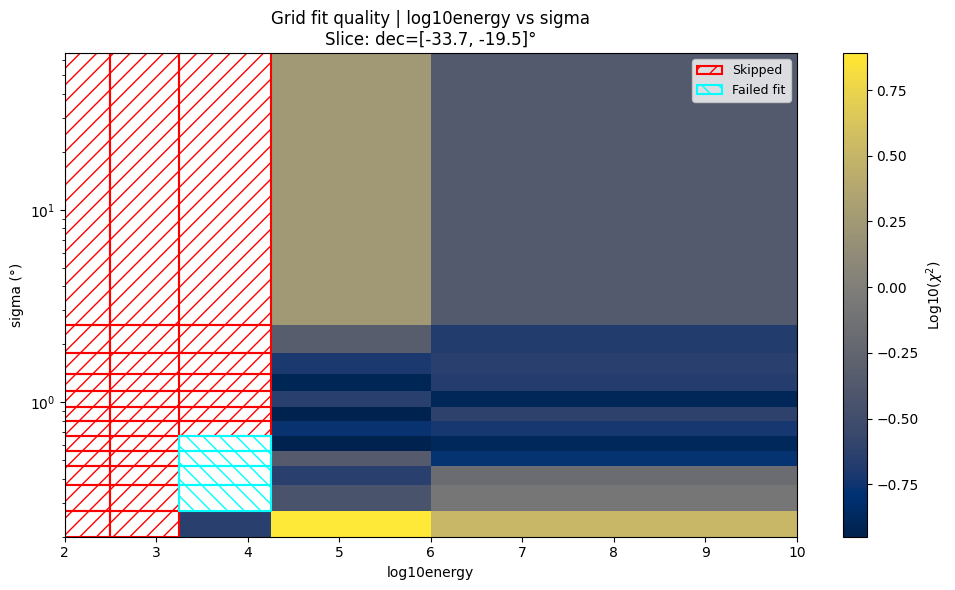

<Axes: title={'center': 'Grid fit quality | log10energy vs sigma\nSlice: dec=[-33.7, -19.5]°'}, xlabel='log10energy', ylabel='sigma (°)'>

: 

In [ ]:
dec_bins = cfg["parametrization_bins"]["dec"]
dec_idx = 2 
#dec_idx = len(dec_bins) // 2 - 1

hidden_slices = {"dec": dec_idx}

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=alpha_vals,
    title="Grid fitted $\\alpha$ | log10energy vs sigma",
    cbar_label="$\\alpha$ (degrees)",
    cmap="viridis",
    y_to_degrees=True,
    value_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,

)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=beta_vals,
    title="Grid fitted $\\beta$ | log10energy vs sigma",
    cbar_label="$\\beta$",
    cmap="plasma",
    y_to_degrees=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,

)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=event_counts,
    title="Grid event counts | log10energy vs sigma",
    cbar_label="log10(#Events)",
    cmap="magma",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,

)

fplt.plot_grid_fit_2d(
    fit_parameters,
    x_name="log10energy",
    y_name="sigma",
    values=fit_quality_chi2,
    title="Grid fit quality | log10energy vs sigma",
    cbar_label="Log10($\\chi^2$)",
    cmap="cividis",
    y_to_degrees=True,
    log_values=True,
    log_y_scale=True,
    hidden_slices=hidden_slices,
)

### test for bias

In [21]:
#load rayleigh reference:
rayleigh_bias_path = os.path.join(rayleigh_benchmark_path, f'rayleigh_bias_{fitting_candidate_sin_dec}_N_100000_rayleigh_benchmark_gamma_2.5.json' )
with open(rayleigh_bias_path, "rb") as f:
    ray_allt = pickle.load(f)

In [22]:


test_for_bias_filepath = os.path.join(run_folder, fitting_candidate, f"king_bias_{fitting_candidate_sin_dec}_{candidate_id}.pkl")
n_sigs = np.r_[:101:10]
if not os.path.exists(test_for_bias_filepath):
    #run test for bias:
    
    trials = [get_many_fits_from_trials(tr = tr,
                                    n_trials= 100, 
                                    n_sig=n_sig, 
                                    logging=True, 
                                    mp_cpus = 16,
                                    seed=int(n_sig)) for n_sig in n_sigs]

    #We add the true number of events injected for bookkeeping convenience:
    for (n_sig, t) in zip(n_sigs, trials):
        t['ntrue'] = np.repeat(n_sig, len(t))

    #Concatenate the trial batches:
    allt = cy.utils.Arrays.concatenate(trials)
    with open(test_for_bias_filepath, "wb") as f:
        pickle.dump(allt, f)
else:
    with open(test_for_bias_filepath, "rb") as f:
        allt = pickle.load(f)

In [6]:
expect_gamma = 2.5
dns = np.mean(np.diff(n_sigs))
ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]


NameError: name 'n_sigs' is not defined

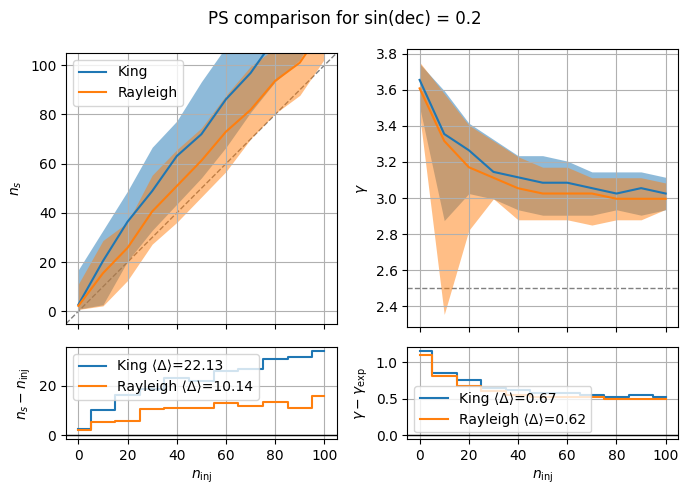

In [24]:
fig, axs = plt.subplots(
    2, 2,
    figsize=(7, 5),
    sharex="col",
    gridspec_kw={"height_ratios": [3, 1]},
)

# ---------- n_s plot ----------
ax = axs[0, 0]
rax = axs[1, 0]

h_king = hl.hist(
    (allt["ntrue"], allt["ns"]),
    bins=(ns_bins, 100),
).contain_project(1)

h_ray = hl.hist(
    (ray_allt["ntrue"], ray_allt["ns"]),
    bins=(ns_bins, 100),
).contain_project(1)

hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

x_ns = h_king.centers[0]

# deviation from expectation: n_s = n_inj
king_dev = h_king.values - x_ns
ray_dev  = h_ray.values - x_ns

# mean absolute deviation
king_mean_dev = np.mean(np.abs(king_dev))
ray_mean_dev  = np.mean(np.abs(ray_dev))

rax.axhline(0, color="k", lw=1)
rax.plot(
    x_ns,
    king_dev,
    drawstyle="steps-mid",
    label=f"King ⟨Δ⟩={king_mean_dev:.2f}",
)
rax.plot(
    x_ns,
    ray_dev,
    drawstyle="steps-mid",
    label=f"Rayleigh ⟨Δ⟩={ray_mean_dev:.2f}",
)

lim = ns_bins[[0, -1]]
ax.plot(lim, lim, color="grey", ls="--", lw=1, zorder=-10)

ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_aspect("equal")

ax.set_ylabel(r"$n_s$")
rax.set_ylabel(r"$n_s - n_\mathrm{inj}$")
rax.set_xlabel(r"$n_\text{inj}$")

# ---------- gamma plot ----------
ax = axs[0, 1]
rax = axs[1, 1]

h_king = hl.hist(
    (allt["ntrue"], allt["gamma"]),
    bins=(ns_bins, 100),
).contain_project(1)

h_ray = hl.hist(
    (ray_allt["ntrue"], ray_allt["gamma"]),
    bins=(ns_bins, 100),
).contain_project(1)

hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

x_gamma = h_king.centers[0]

# reference line: gamma = expect_gamma
gamma_ref = expect_gamma

king_dev = h_king.values - gamma_ref
ray_dev  = h_ray.values - gamma_ref

# mean deviation
king_mean_dev = np.mean(np.abs(king_dev))
ray_mean_dev  = np.mean(np.abs(ray_dev))

rax.axhline(0, color="k", lw=1)
rax.plot(
    x_gamma,
    king_dev,
    drawstyle="steps-mid",
    label=f"King ⟨Δ⟩={king_mean_dev:.2f}",
)
rax.plot(
    x_gamma,
    ray_dev,
    drawstyle="steps-mid",
    label=f"Rayleigh ⟨Δ⟩={ray_mean_dev:.2f}",
)

ax.axhline(gamma_ref, color="grey", ls="--", lw=1, zorder=-10)
ax.set_xlim(axs[0, 0].get_xlim())

ax.set_ylabel(r"$\gamma$")
rax.set_ylabel(r"$\gamma - \gamma_\mathrm{exp}$")
rax.set_xlabel(r"$n_\text{inj}$")

for ax in axs.flat:
    ax.grid()

axs[0, 0].legend()
axs[1, 0].legend()
axs[1, 1].legend()

fig.suptitle(f"PS comparison for sin(dec) = {fitting_candidate_sin_dec}")
fig.tight_layout()
plt.show()

### sample fit plots

Found 361 bins with stored fits
Showing best bins:
1: bin=(1, 4, 3), CDF_chi2=2.374


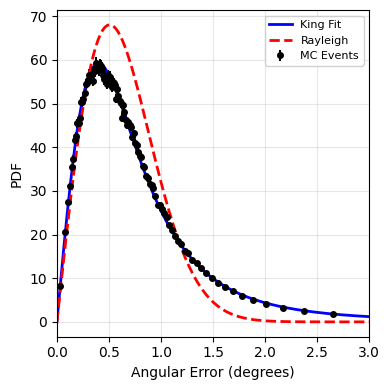

{'log10energy': {'index': 1, 'low': 2.5, 'high': 3.25},
 'dec': {'index': 4, 'low': -0.1113410132229299, 'high': 0.1113410132229299},
 'sigma': {'index': 3,
  'low': 0.008090057410299778,
  'high': 0.009767032228410244}}

In [12]:
bin_indices = [1,4, 3]

fplt.plot_selected_fit_bins(
    fit_parameters,
    mode="best",
    metric = 'CDF_chi2',
    x_log = False,
    y_log = False,
    normalize_fit_to_hist= False,
    plot_kind= 'radial',
    gamma_idx= gamma_idx,
    n_plots=1,
    show_data= False,
    figsize = (4, 4),
    minimum_counts=cfg['minimum_counts'],
    show_rayleigh_ref = True, 
    signal_events = ana[0].sig.as_array,
    king_pdf = king_wrapper.king_pdf,
    selected_bin_idx= bin_indices,
    x_lim = 3
    )
get_bin_info(fit_parameters["parametrization_bins"], bin_indices)

In [25]:
np.deg2rad(6.38)
np.rad2deg(-0.89)

-50.99324376664327

### TS distribution

In [ ]:
king_trials = np.load(os.path.join(run_folder, fitting_candidate, f'king_bkg_trials_sindec_{fitting_candidate_sin_dec}_N_1000_SINDEC_{fitting_candidate_sin_dec}_NTRIALS_1000_{fitting_candidate}.npy'))
king_cached_trials = cy.utils.Arrays(king_trials)
#apply fits
king_bg = cy.dists.Chi2TSD(king_cached_trials)



In [7]:
#rayleigh bg trials for reference:
ray_df = pd.read_csv(os.path.join(rayleigh_benchmark_path, f'bkg_trials_sin_dec_{fitting_candidate_sin_dec}.csv'))
ray_cached_trials = cy.utils.Arrays(ray_df)
#apply fits
ray_bg = cy.dists.Chi2TSD(ray_cached_trials)

inject signal in both

In [8]:
N_sig = 30

In [ ]:

#king
king_with_sig = cy.dists.Chi2TSD(get_many_fits_from_trials(tr = tr,
                                    n_trials= 1000, 
                                    n_sig=N_sig, 
                                    logging=True, 
                                    mp_cpus = 16,
                                    seed=42))
#rayleigh, here we have to also rebuild tr


Performing 1000 trials with n_sig=30 using 32 cores:


17/1000

OpenBLAS blas_thread_init: pthread_create failed for thread 11 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_init: or set a smaller OPENBLAS_NUM_THREADS to fit into what you have available
OpenBLAS blas_thread_init: RLIMIT_NPROC 1027118 current, 1027118 max
OpenBLAS blas_thread_init: pthread_create failed for thread 12 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_init: or set a smaller OPENBLAS_NUM_THREADS to fit into what you have available
OpenBLAS blas_thread_init: RLIMIT_NPROC 1027118 current, 1027118 max
OpenBLAS blas_thread_init: pthread_create failed for thread 13 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_

40/1000

OpenBLAS blas_thread_init: pthread_create failed for thread 1 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_init: or set a smaller OPENBLAS_NUM_THREADS to fit into what you have available
OpenBLAS blas_thread_init: RLIMIT_NPROC 1027118 current, 1027118 max
OpenBLAS blas_thread_init: pthread_create failed for thread 2 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_init: or set a smaller OPENBLAS_NUM_THREADS to fit into what you have available
OpenBLAS blas_thread_init: RLIMIT_NPROC 1027118 current, 1027118 max
OpenBLAS blas_thread_init: pthread_create failed for thread 3 of 64: Resource temporarily unavailable
OpenBLAS blas_thread_init: ensure that your address space and process count limits are big enough (ulimit -a)
OpenBLAS blas_thread_ini

626/1000
KeyboardInterrupt: terminating workers.


KeyboardInterrupt: 

In [9]:
ray_tr: cy.trial.TrialRunner = cy.get_trial_runner(
    src = cy.sources(0, np.arcsin(fitting_candidate_sin_dec)), 
    ana = ana, 
    mp_cpus = 32,
    flux = cy.hyp.PowerLawFlux(expect_gamma))

ray_with_sig: cy.utils.Arrays = cy.dists.Chi2TSD(ray_tr.get_many_fits(n_trials = 1000, 
                                                 n_sig = N_sig,
                                                 seed= 42, 
                                                 mp_cpus= 16))

Performing 1000 trials with n_sig = 30.000 using 16 cores:
       1000/1000 trials complete.   


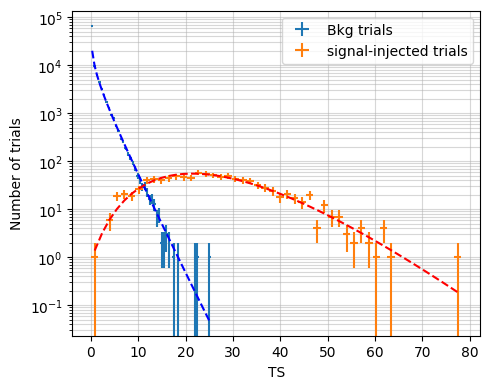

In [19]:
fig, ax = plt.subplots(figsize=(5, 4))

# ---------------- Background trials ----------------
h_bg = ray_bg.get_hist(bins=50)

hl.plot1d(
    ax,
    h_bg,
    crosses=True,
    color="C0",
    label=f"Bkg trials",
)

x_bg = h_bg.centers[0]
norm_bg = h_bg.integrate().values

ax.semilogy(
    x_bg,
    norm_bg * ray_bg.pdf(x_bg),
    lw=1.5,
    ls="--",
    color="b",
)

""" ax.axvline(
    ray_bg.median(),
    color="C0",
    linestyle=":",
    label=rf"Bkg median: {ray_bg.median():.2f}",
)
 """

# ---------------- Signal-injected trials ----------------
h_sig = ray_with_sig.get_hist(bins=50)

hl.plot1d(
    ax,
    h_sig,
    crosses=True,
    color="C1",
    label=f"signal-injected trials",
)

x_sig = h_sig.centers[0]
norm_sig = h_sig.integrate().values

ax.semilogy(
    x_sig,
    norm_sig * ray_with_sig.pdf(x_sig),
    lw=1.5,
    ls="--",
    color="r",

)

""" ax.axvline(
    ray_with_sig.median(),
    color="C1",
    linestyle=":",
    label=rf"Signal median: {ray_with_sig.median():.2f}",
) """


# ---------------- Formatting ----------------
ax.grid(which="both", alpha=0.5)
ax.set_xlabel("TS")
ax.set_ylabel("Number of trials")
#ax.set_title(rf"$\sin(\delta) = {fitting_candidate_sin_dec:.2f}$")
ax.legend()

plt.tight_layout()
plt.show()
plt.close(fig)

In [ ]:
fplt.plot_TS_signal_ray_vs_king(
    src_sin_dec= fitting_candidate_sin_dec,
    king_bkg = king_bg,
    ray_bkg= ray_bg,
    king_sig= king_with_sig,
    ray_sig = ray_with_sig, 
    n_sig_ray = N_sig,
    n_sig_king= N_sig
)

## Box plot of Ratio (src-regional performance)

In [ ]:
sorted_keys = sorted(region_ratios.keys())
data = [region_ratios[k] for k in sorted_keys]

plt.figure(figsize = (8, 4))
plt.axhline(1, color="black", lw=1, ls="--")
plt.axhspan(1, 1.5, color = 'red', alpha = 0.1)
plt.axhspan(0.7, 1, color = 'lime', alpha = 0.1)
plt.boxplot(
    data,
    positions=sorted_keys,   # x-positions of the boxes
    widths=0.02,             # adjust to your spacing
    showfliers=False,        # optional
    manage_ticks=False,
)
plt.ylim(0.8, 1.33)
plt.xlabel(r"$\sin{(\mathrm{dec})}$")
plt.ylabel(r"$\Phi_{\rm King}/\Phi_{\rm Rayleigh}$")
plt.grid(which="both", zorder=1)